 # **Boston Housing Market Dataset: Socioeconomic and Environmental Determinants of Median Home Value**

#**Executive Summary**

The Boston Housing Market Dataset captures key socioeconomic, environmental, and infrastructural characteristics of neighborhoods in the Boston metropolitan area and their relationship with housing prices. The dataset is widely used for exploratory data analysis, regression modeling, and machine learning tasks, particularly in understanding how factors such as crime rate, air pollution, accessibility, and education quality influence residential property values.

With 14 variables describing neighborhood conditions and a target variable representing median home value, the dataset provides a robust foundation for predictive modeling, policy analysis, and urban planning insights. It is especially valuable for demonstrating supervised learning techniques and assessing structural inequalities embedded in urban housing markets.

#Business Context

Urban housing prices are influenced by a complex interaction of environmental quality, public infrastructure, socioeconomic status, and accessibility. Policymakers, urban planners, and data scientists need to understand which neighborhood-level factors most strongly affect housing values and how these factors interact.

This dataset can be used to address the following problem:

How do socioeconomic, environmental, and infrastructural variables influence median housing prices in Boston neighborhoods, and can these variables be used to accurately predict housing values?

Typical analytical objectives include:

Predicting median house prices using regression and machine learning models

Identifying the most influential determinants of housing value

Exploring inequality patterns across neighborhoods

Demonstrating feature importance, multicollinearity, and model interpretability




#Data Dictionary

**Variable	Description**

1. CRIM:  Per capita crime rate by town
2. ZN:	Proportion of residential land zoned for lots over 25,000 sq.ft
3. INDUS:	Proportion of non-retail business acres per town
4. CHAS:	Charles River dummy variable (1 if tract bounds river, 0 otherwise)
5. NOX:	Nitric oxide concentration (parts per 10 million)
6. RM:	Average number of rooms per dwelling
7. AGE:	Proportion of owner-occupied units built prior to 1940
8. DIS:	Weighted distances to five Boston employment centers
9. RAD:	Index of accessibility to radial highways
10. TAX:	Full-value property tax rate per $10,000
11. PTRATIO:	Pupil–teacher ratio by town
12. B:	Proportion of Black residents, transformed as
1000
(
𝐵
𝑘
−
0.63
)
2
1000(Bk−0.63)
2

13. LSTAT:	Percentage of lower-status population
14. MEDV:	Median value of owner-occupied homes (in $1000s) — Target variable

## Importing necessary libraries

In [46]:
# this will help in making the Python code more structured automatically when coding with Jupiter(good coding practice)
#%load_ext nb_black

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# split the data into train and test
from sklearn.model_selection import train_test_split

# to build linear regression_model
import statsmodels.api as sm

# to check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# To help with reading and manipulating data
import pandas as pd
import numpy as np

# To help with data visualization
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# To be used for missing value imputation
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer

# To help with model building
from sklearn.linear_model import LogisticRegression,RidgeClassifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from sklearn.ensemble import  AdaBoostRegressor



# To get different metric scores, and split data
from sklearn import metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)
#Libraries for oversampling and undersampling imbalance target data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import make_pipeline
from imblearn.pipeline import Pipeline



#Libraries to help with regularization models
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To be used for tuning the model
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# To be used for creating pipelines and personalizing them

from sklearn.compose import ColumnTransformer
from imblearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To supress warnings
import warnings

warnings.filterwarnings("ignore")


from sklearn.feature_selection import f_classif, VarianceThreshold
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests


from sklearn.compose import ColumnTransformer

import scipy.stats as stats

## Loading the dataset

In [ ]:
project=pd.read_csv("HousingData.csv")

In [ ]:
df=project.copy()

## Data Overview

- Observations
- Sanity checks

In [ ]:
# let's check the shape of the data
df.shape

(506, 14)

- There are 3454 rows and 15 columns in the dataset.

In [ ]:
 #let's check the first 5 rows of the data
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.006,18.000,2.310,0.000,0.538,6.575,65.200,4.090,1,296,15.300,396.900,4.980,24.000
1,0.027,0.000,7.070,0.000,0.469,6.421,78.900,4.967,2,242,17.800,396.900,9.140,21.600
2,0.027,0.000,7.070,0.000,0.469,7.185,61.100,4.967,2,242,17.800,392.830,4.030,34.700
3,0.032,0.000,2.180,0.000,0.458,6.998,45.800,6.062,3,222,18.700,394.630,2.940,33.400
4,0.069,0.000,2.180,0.000,0.458,7.147,54.200,6.062,3,222,18.700,396.900,NaN,36.200


In [ ]:
# let's check column types and number of values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [ ]:
#Checking statistcal summary
df.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
CRIM,486.000,3.612,8.720,0.006,0.082,0.254,3.560,88.976
ZN,486.000,11.212,23.389,0.000,0.000,0.000,12.500,100.000
INDUS,486.000,11.084,6.836,0.460,5.190,9.690,18.100,27.740
CHAS,486.000,0.070,0.255,0.000,0.000,0.000,0.000,1.000
NOX,506.000,0.555,0.116,0.385,0.449,0.538,0.624,0.871
RM,506.000,6.285,0.703,3.561,5.885,6.208,6.623,8.780
AGE,486.000,68.519,28.000,2.900,45.175,76.800,93.975,100.000
DIS,506.000,3.795,2.106,1.130,2.100,3.207,5.188,12.127
RAD,506.000,9.549,8.707,1.000,4.000,5.000,24.000,24.000
TAX,506.000,408.237,168.537,187.000,279.000,330.000,666.000,711.000


In [ ]:
#Check duplicate values
df.duplicated().sum()

np.int64(0)

- There are no duplicate rows in data set.

In [ ]:
#checking missing values
df.isnull().sum()

,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


## Exploratory Data Analysis (EDA)

###Creating Custom Functions


Defining a custom function to make ploting of Histograms and Boxplots automated for Numerical variables.

In [11]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=df, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=df, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=df, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        df[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram(green line)
    ax_hist2.axvline(
        df[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram(black line)

Defining a custom function to aid in plotting of barplot for analysing the distribution of descrete variables

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

def labeled_barplot(df, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(df[feature])  # length of the column
    count = df[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=df,
        x=feature,
        order=df[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot




In [13]:
#Defining function to plot stacked barplot
def stacked_barplot(data, x, y, normalize=False):
    """
    Stacked bar plot for two categorical variables
    """

    # Defensive check
    if x not in data.columns or y not in data.columns:
        raise KeyError(f"{x} or {y} not found in dataframe")

    ct = pd.crosstab(data[x], data[y], normalize="index" if normalize else False)

    ct.plot(
        kind="bar",
        stacked=True,
        figsize=(8, 5)
    )

    plt.xlabel(x)
    plt.ylabel("Proportion" if normalize else "Count")
    plt.title(f"{x} vs {y}")
    plt.legend(title=y)

In [14]:
# function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data1[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data1[data1[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data1[data1[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data1, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

###**1. Univariate analysis**

<Figure size 640x480 with 0 Axes>

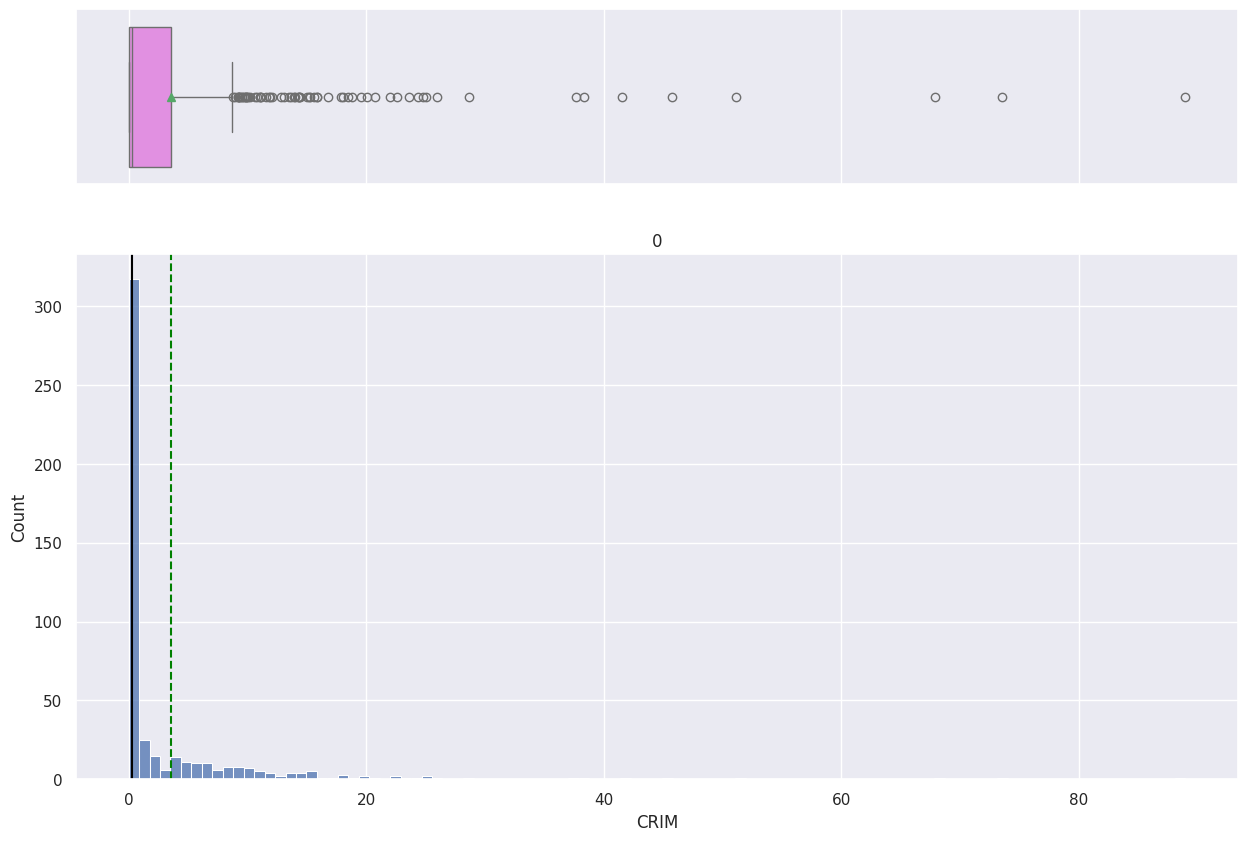

<Figure size 640x480 with 0 Axes>

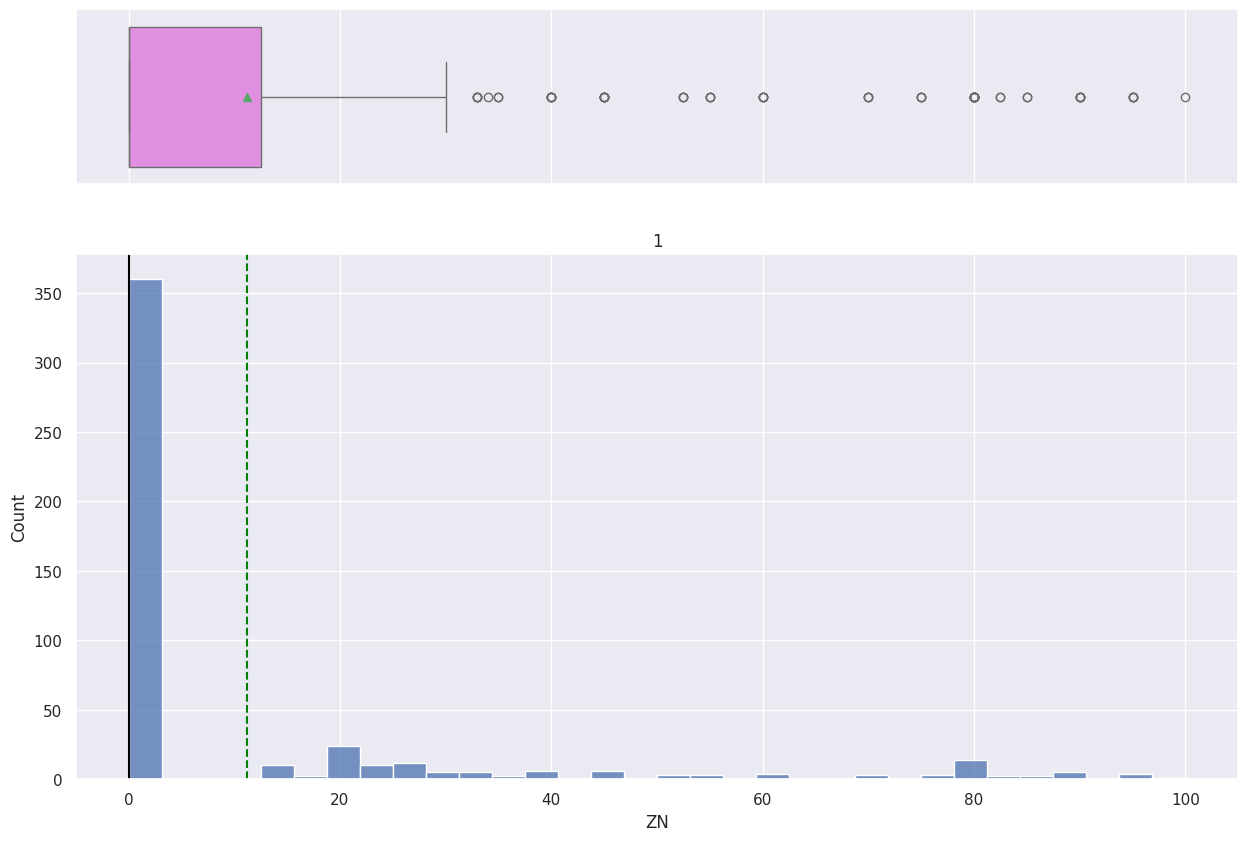

<Figure size 640x480 with 0 Axes>

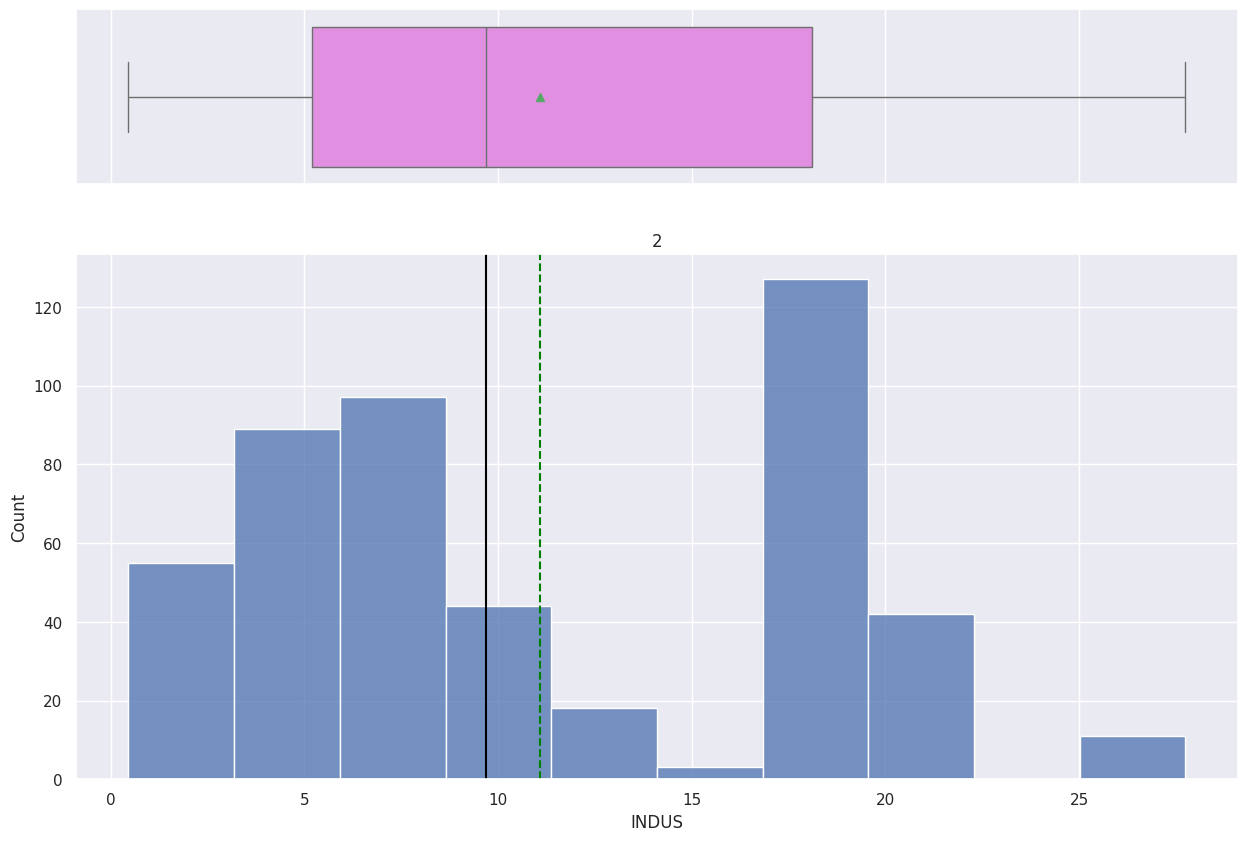

<Figure size 640x480 with 0 Axes>

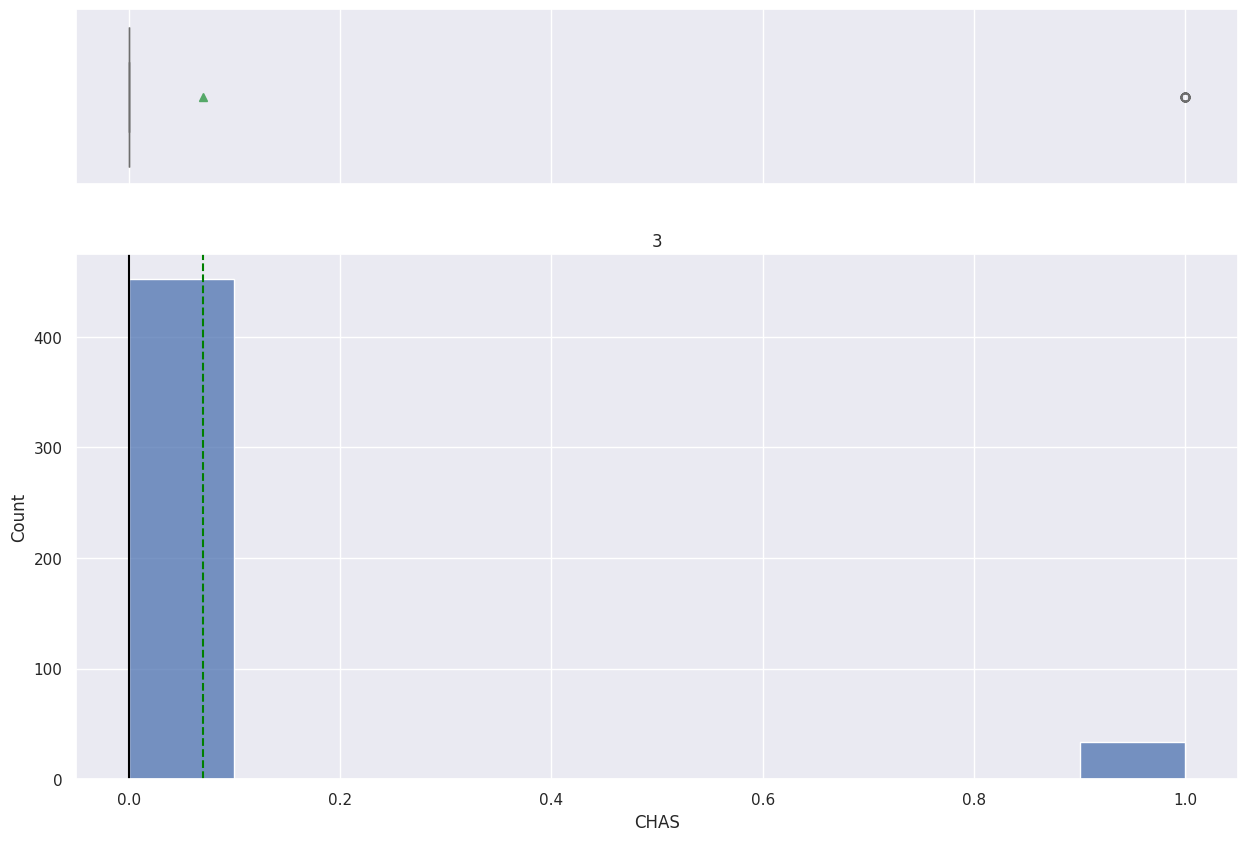

<Figure size 640x480 with 0 Axes>

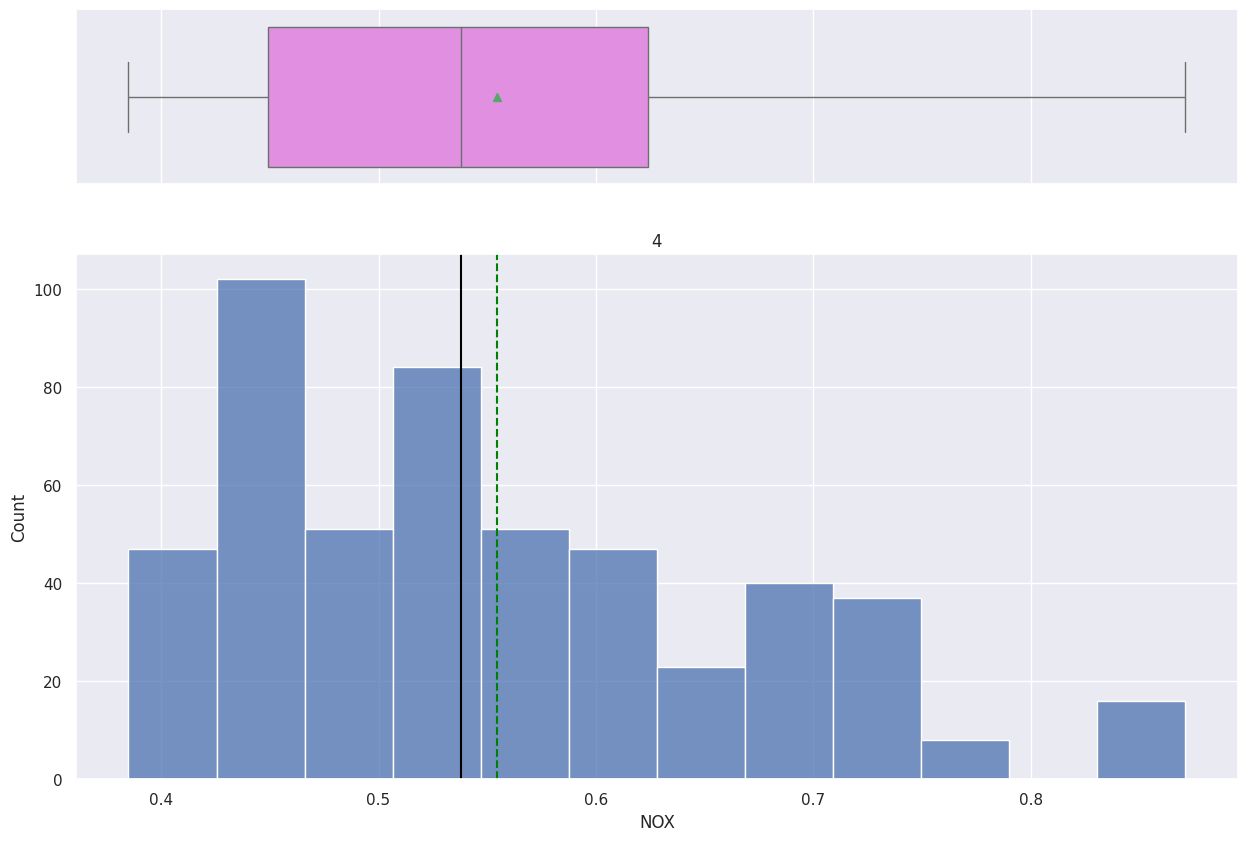

<Figure size 640x480 with 0 Axes>

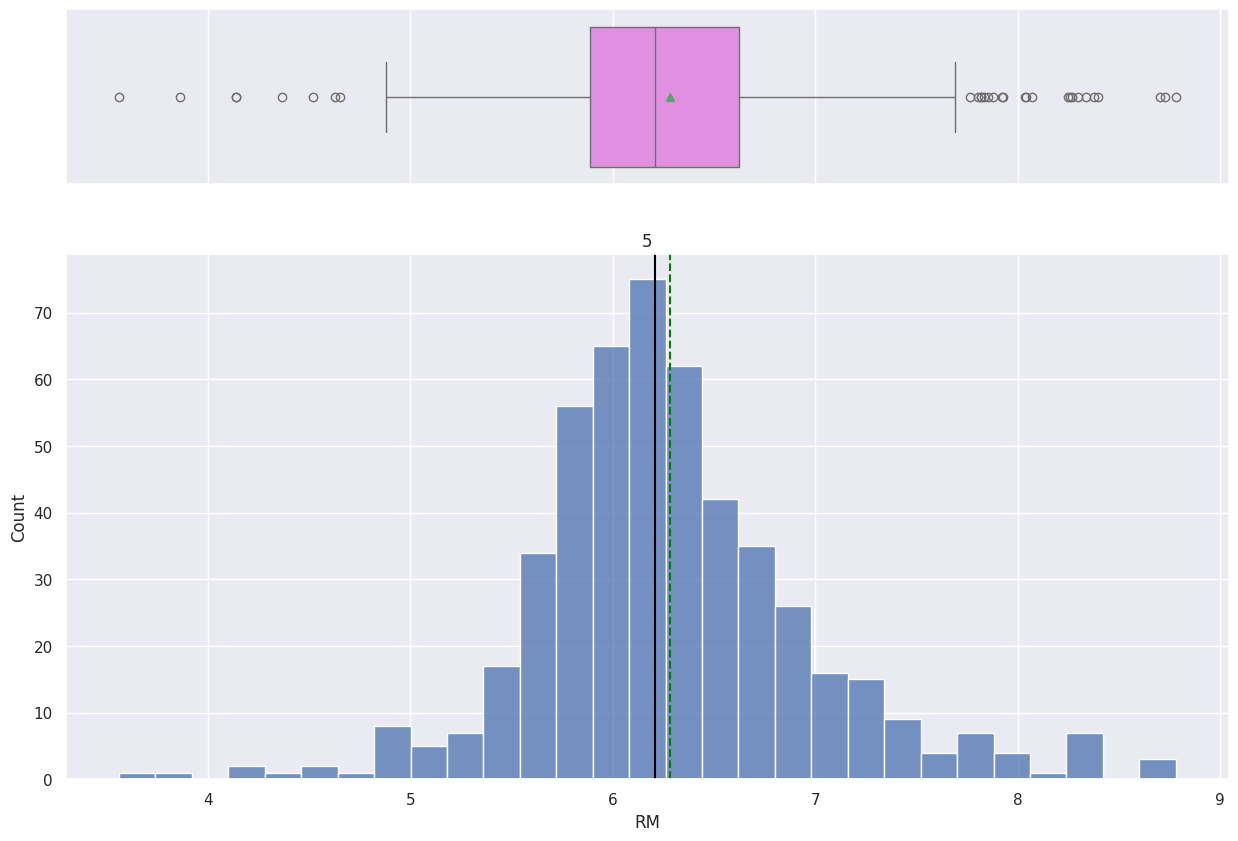

<Figure size 640x480 with 0 Axes>

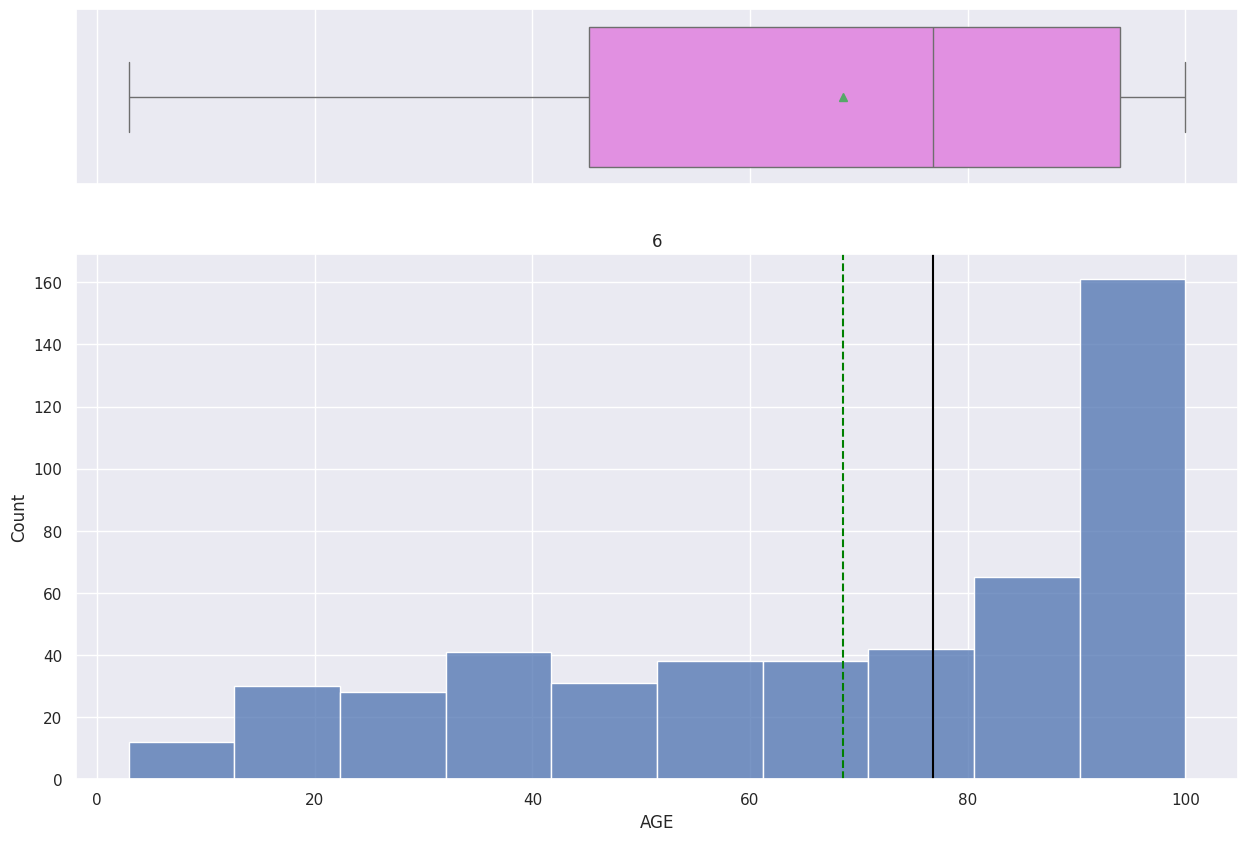

<Figure size 640x480 with 0 Axes>

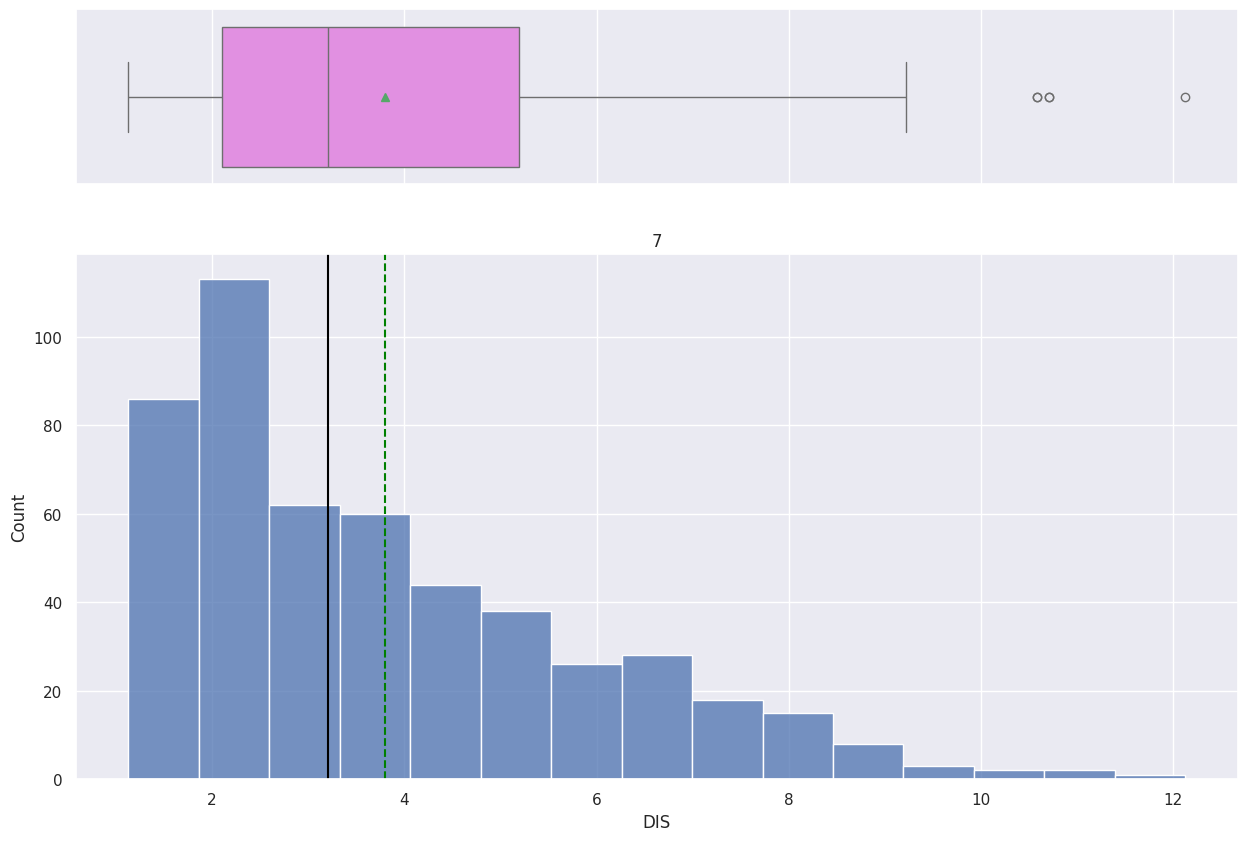

<Figure size 640x480 with 0 Axes>

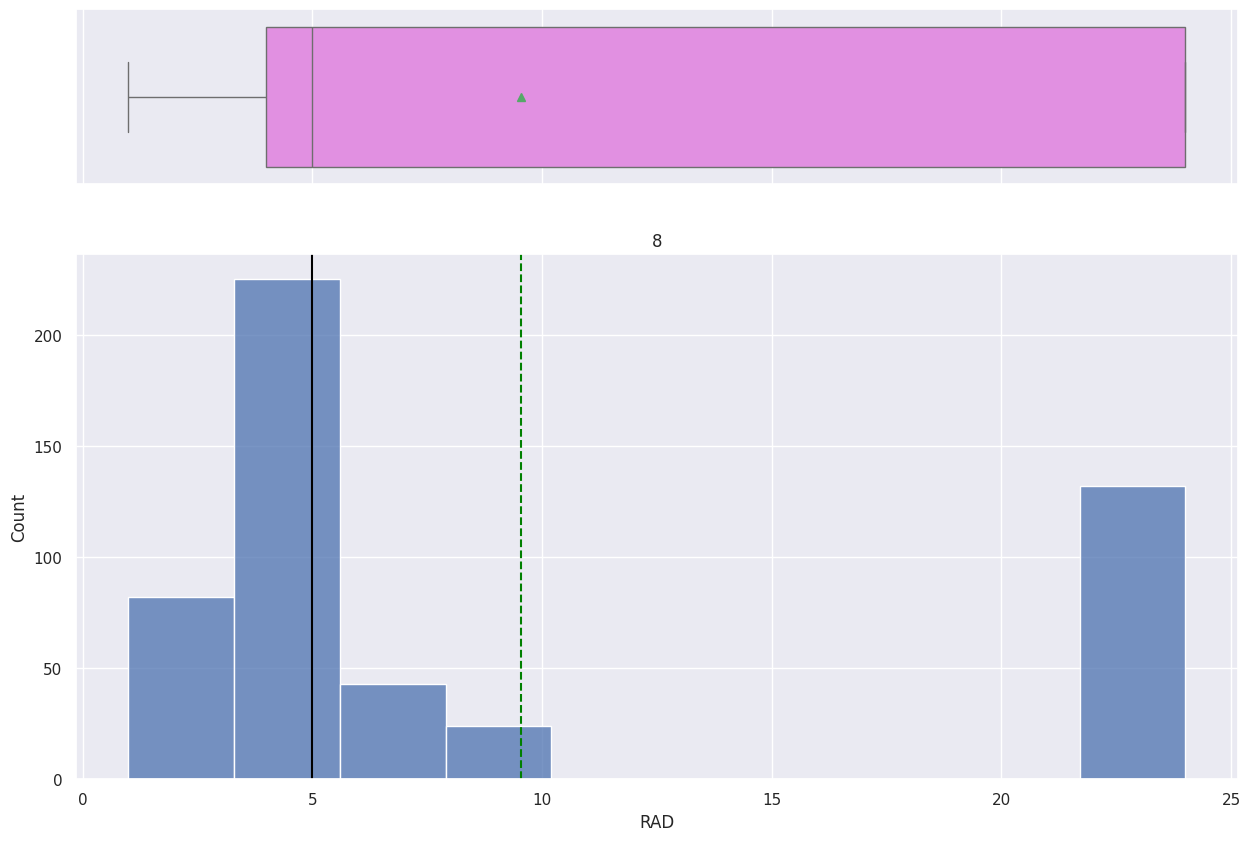

<Figure size 640x480 with 0 Axes>

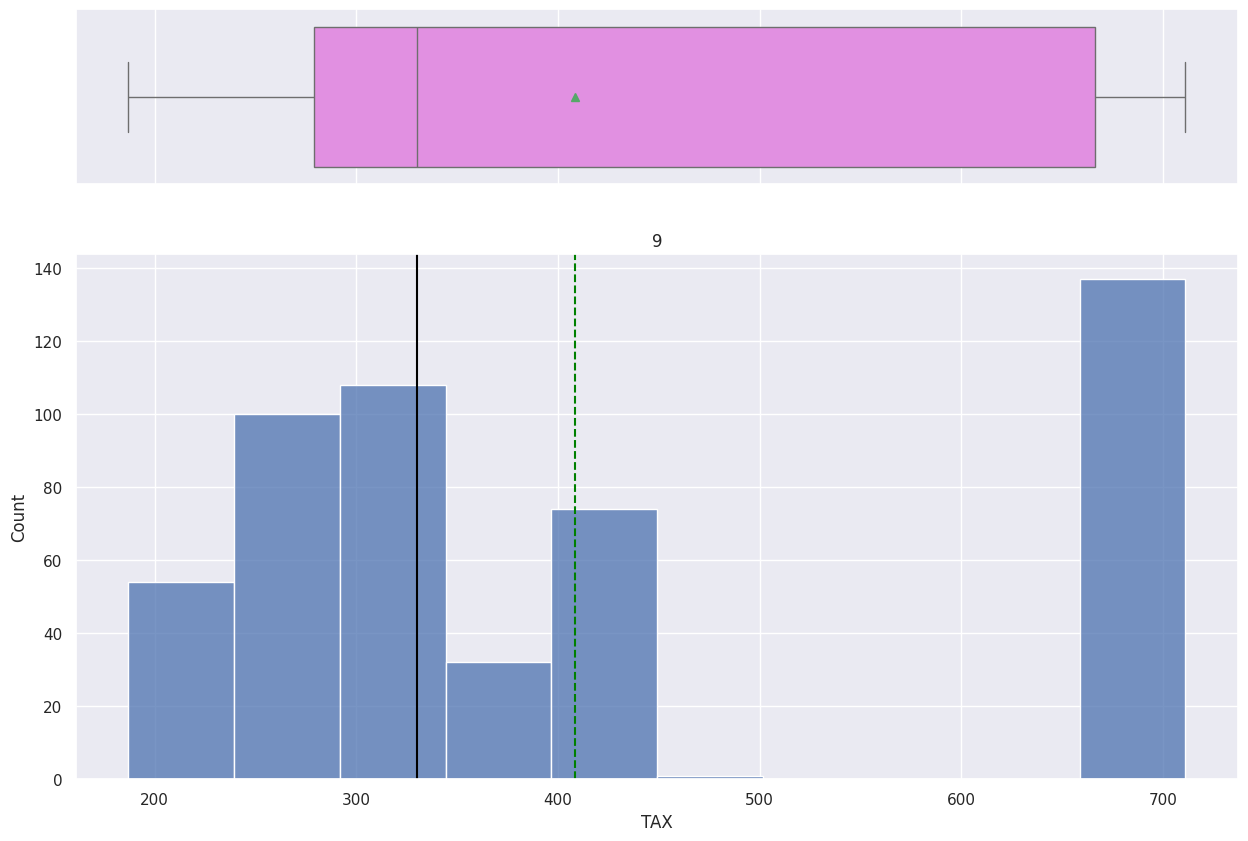

<Figure size 640x480 with 0 Axes>

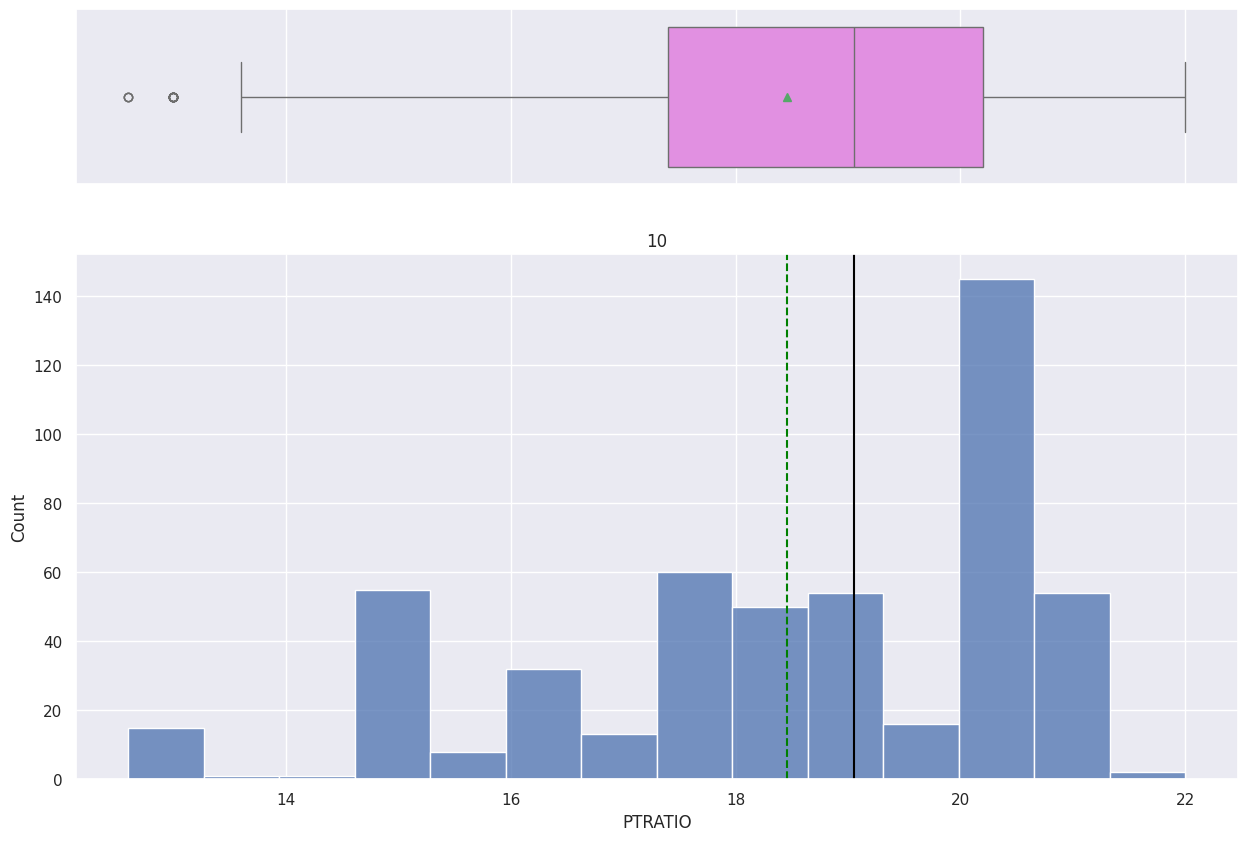

<Figure size 640x480 with 0 Axes>

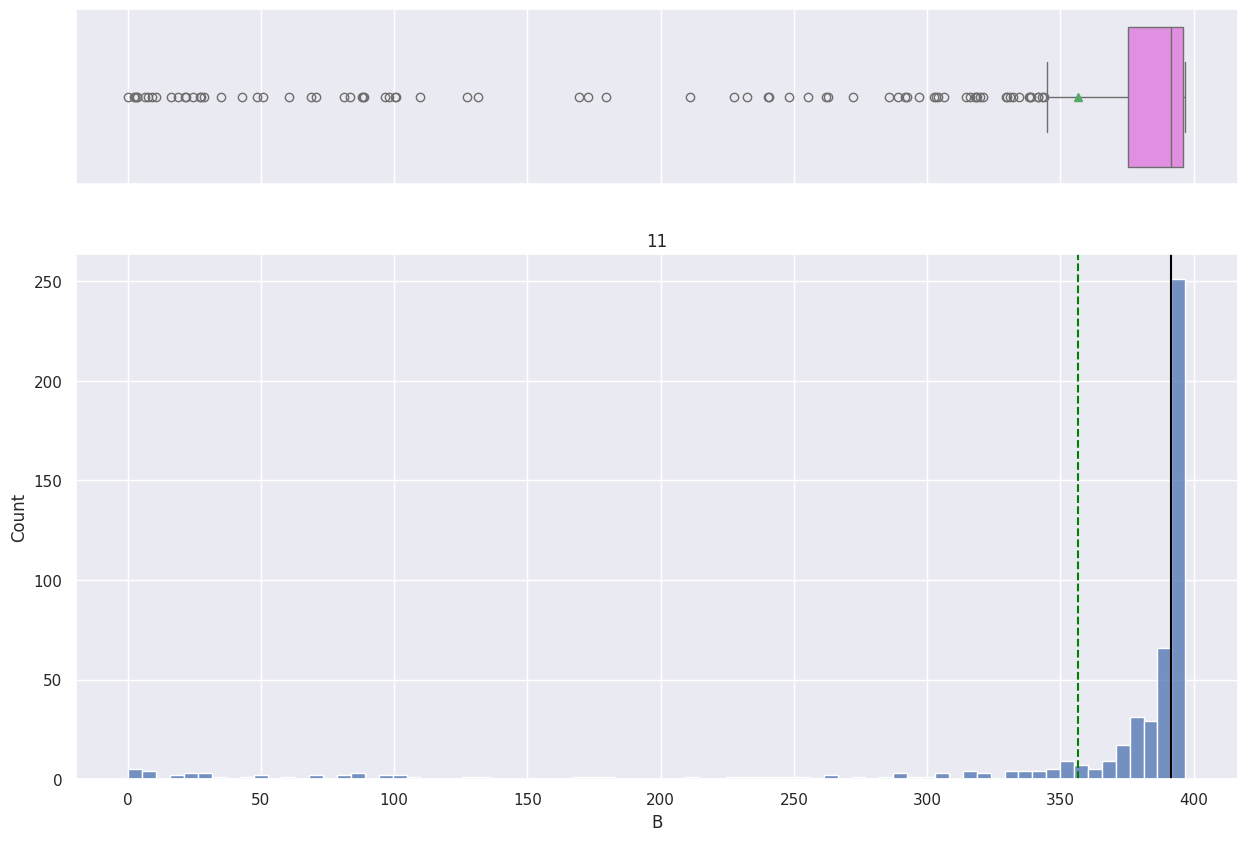

<Figure size 640x480 with 0 Axes>

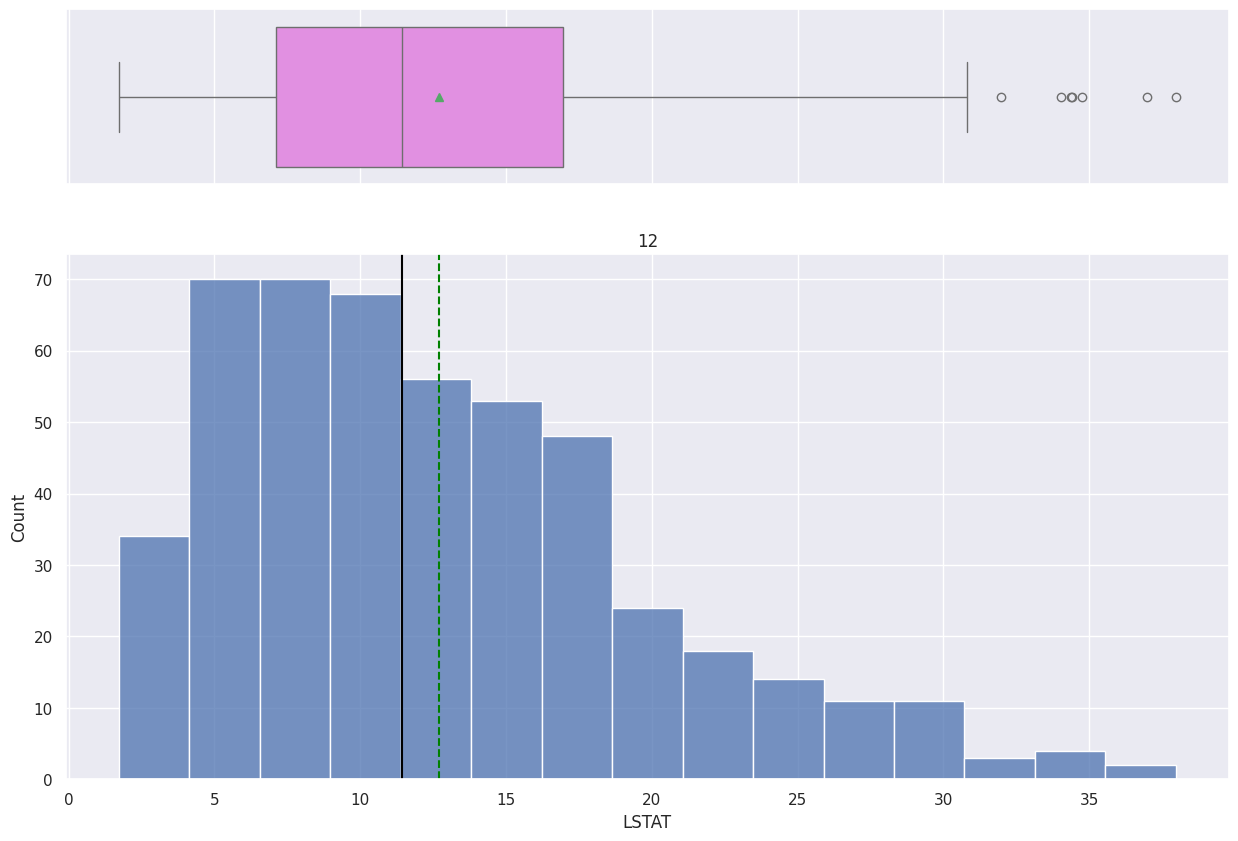

<Figure size 640x480 with 0 Axes>

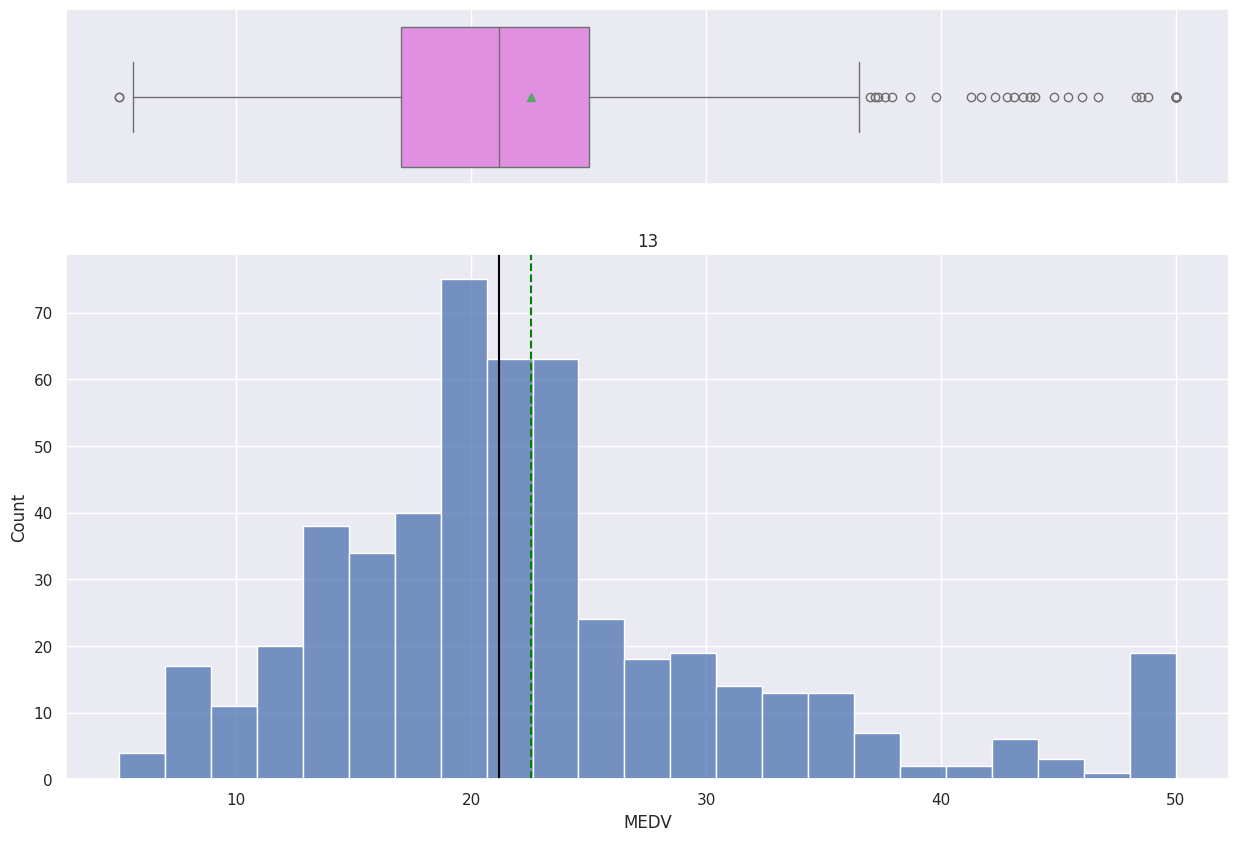

In [15]:
# Check for continuous data types
continuous_cols = df.select_dtypes(include=[np.number])  # Select numeric columns

# Loop through continuous columns
for col in continuous_cols.columns:
    plt.figure()  # Create a new figure for each plot
    histogram_boxplot(df, col)  # Pass the column name (feature)

    # Extract the column title from the DataFrame
    col_title = df.columns.get_loc(col)  # Get the column index and use it to retrieve the title
    plt.title(col_title)  # Set the plot title using the column title
    plt.show()

###2. Bivariate analysis

####Numerical variables against each other

Plotting corrolation heatmap of numerical variables

In [17]:
# creating a list of numerical columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()




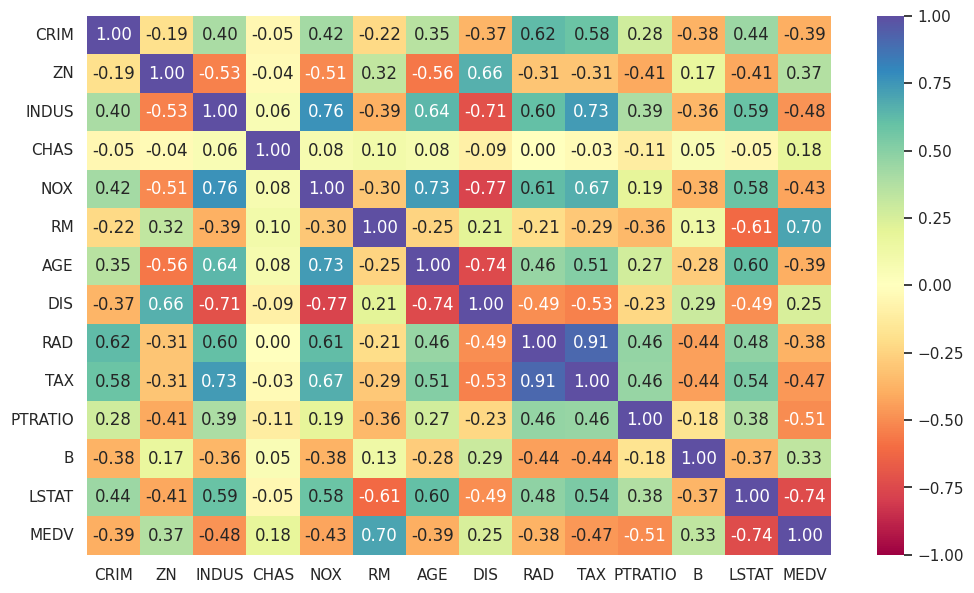

In [18]:
#plotting correlation heat map
plt.figure(figsize=(12, 7))
sns.heatmap(
    df[num_cols].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")

plt.show()

Plotting all numerical variables against each other using a scatterplot

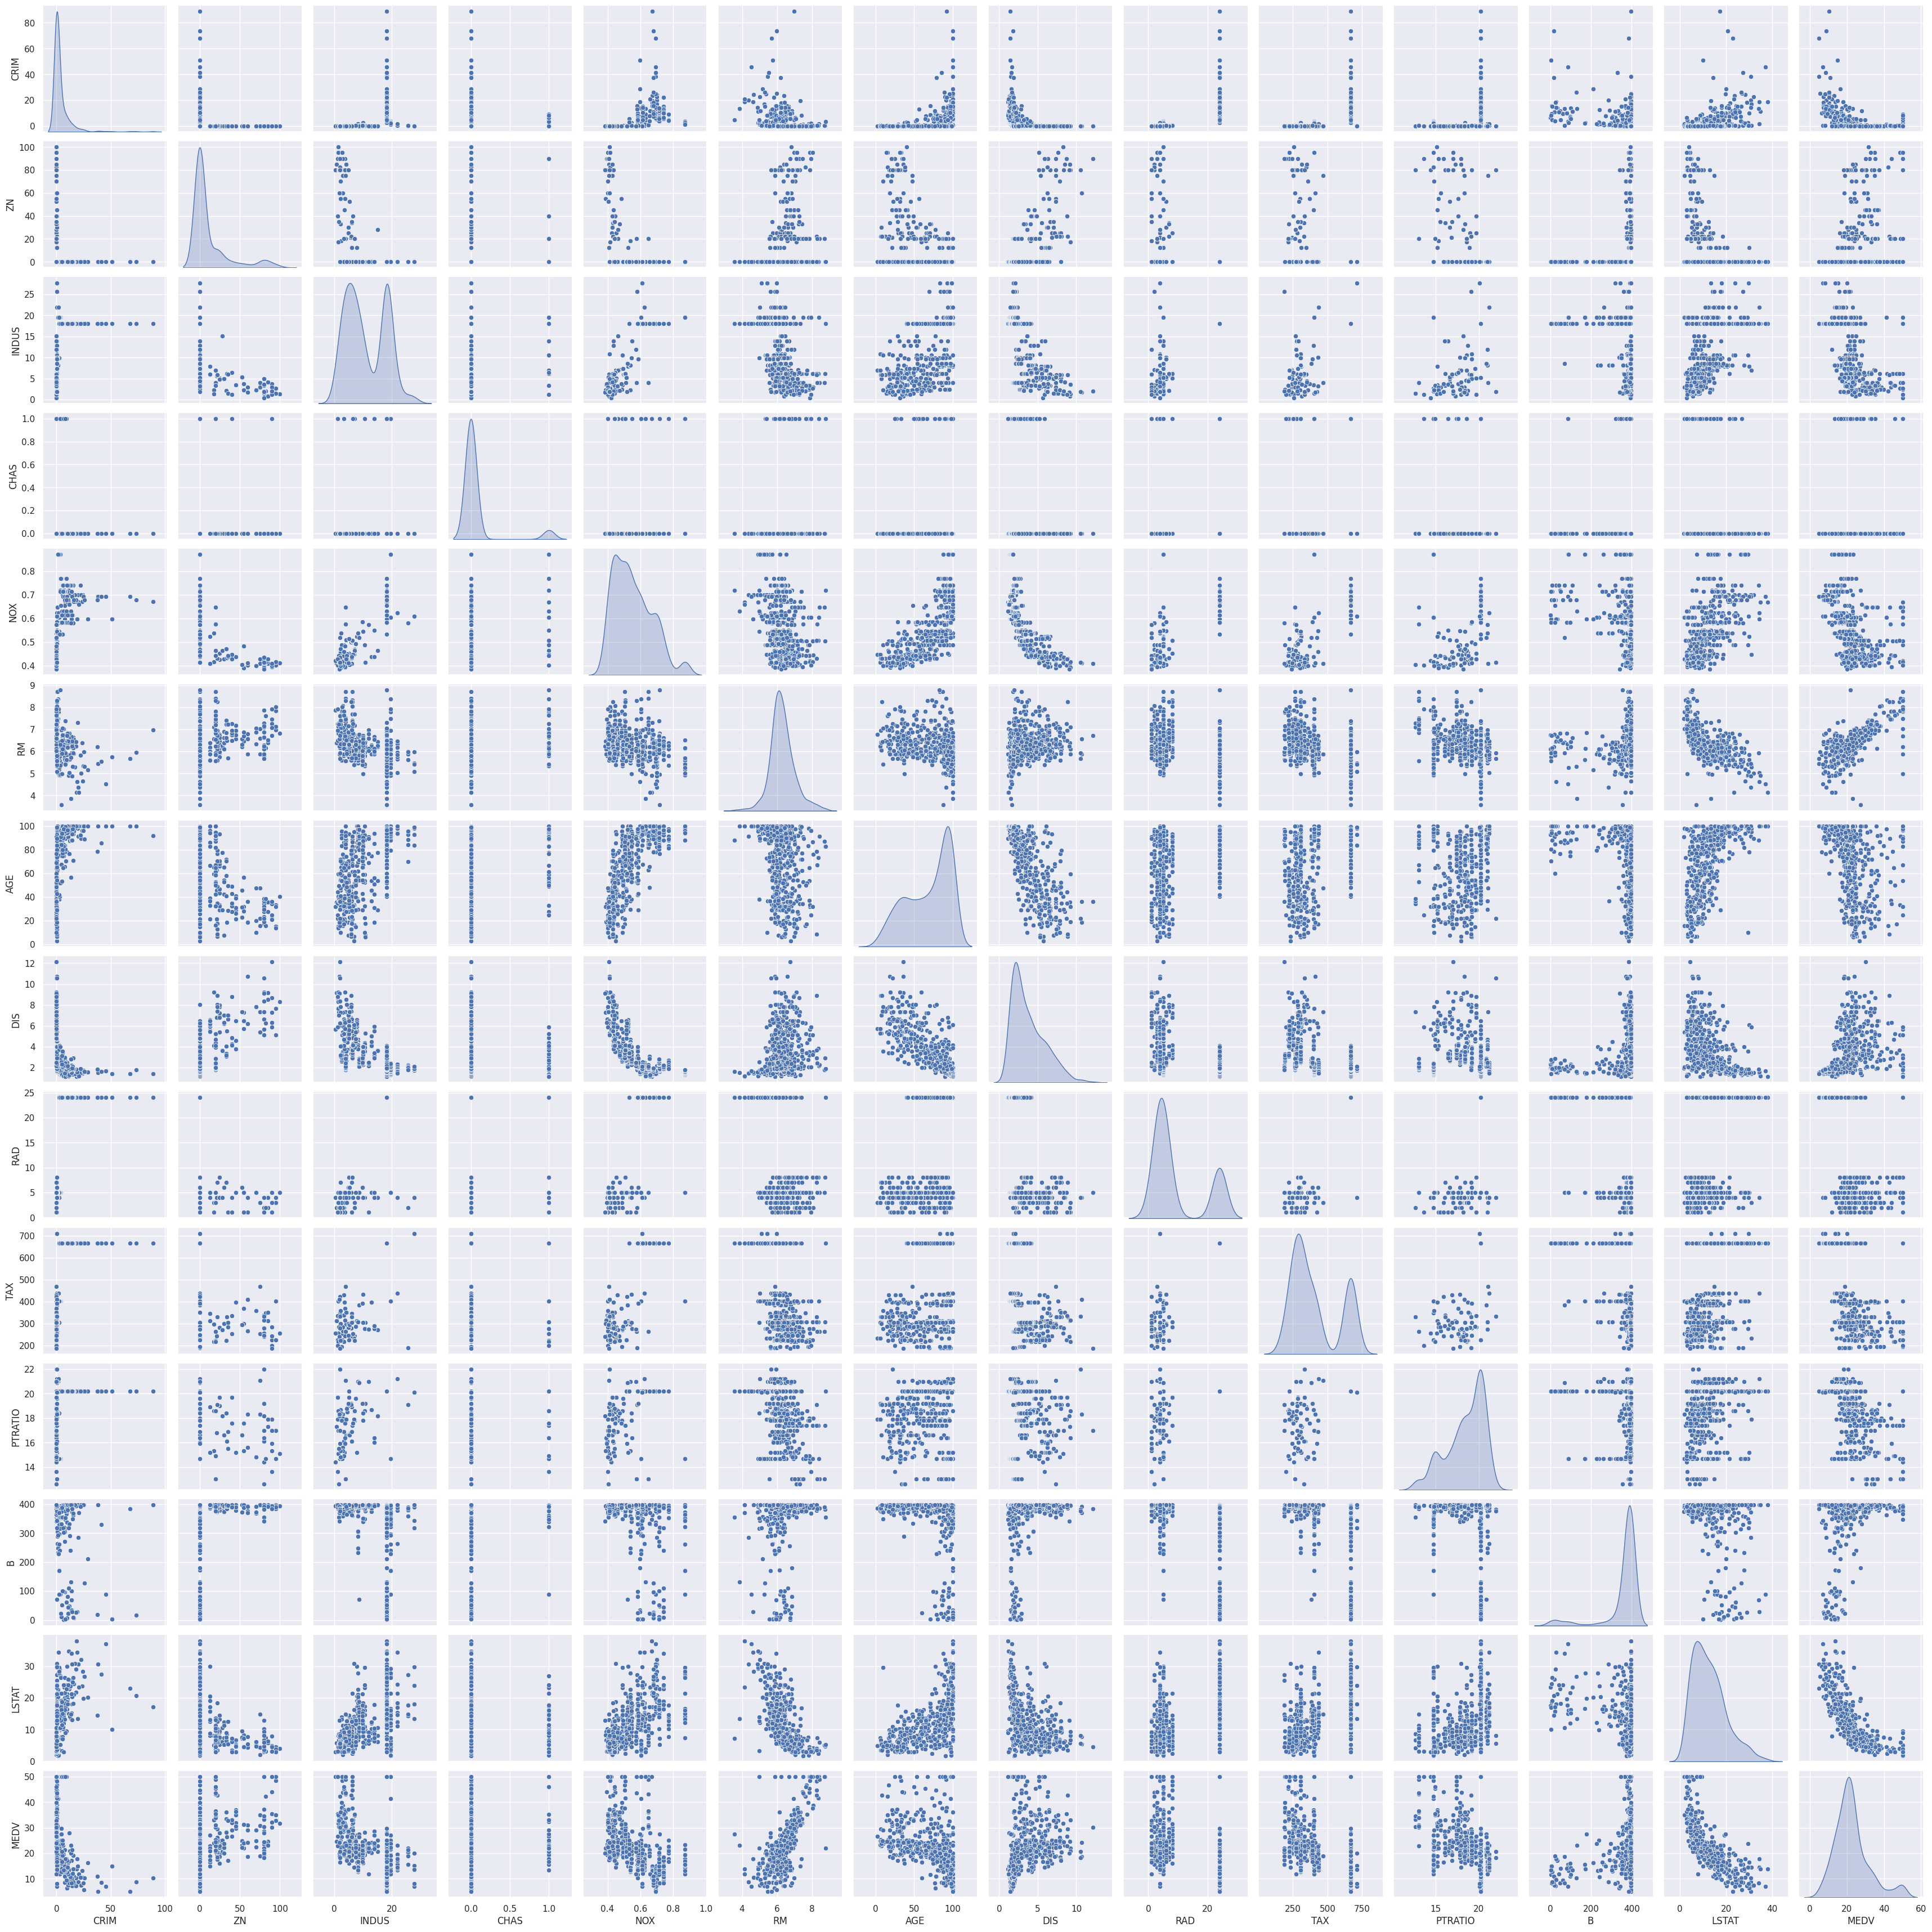

In [19]:
df_attr = df.iloc[:, 0:7]
sns.pairplot(
    df, diag_kind="kde"
)

## Data Preprocessing

- Missing value treatment
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

###**1. Missing value treatment**

In [20]:
#checking missing values
df.isnull().sum()

,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


we need create a copy of our data set to avoid changes to it

In [66]:
df1 = df.copy()

In [67]:
# Numerical features → median imputation
num_features = ["CRIM", "ZN", "INDUS", "AGE", "LSTAT"]
for col in num_features:
    df1[col] = df1[col].fillna(df[col].median())

# Binary feature → mode imputation
df1["CHAS"] = df1["CHAS"].fillna(df["CHAS"].mode()[0])

In [68]:
#checking missing values
df1.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


###**2. Feature Engineering**

###**3. Outlier detection and treatment**

- Lets first visualize all our outliers

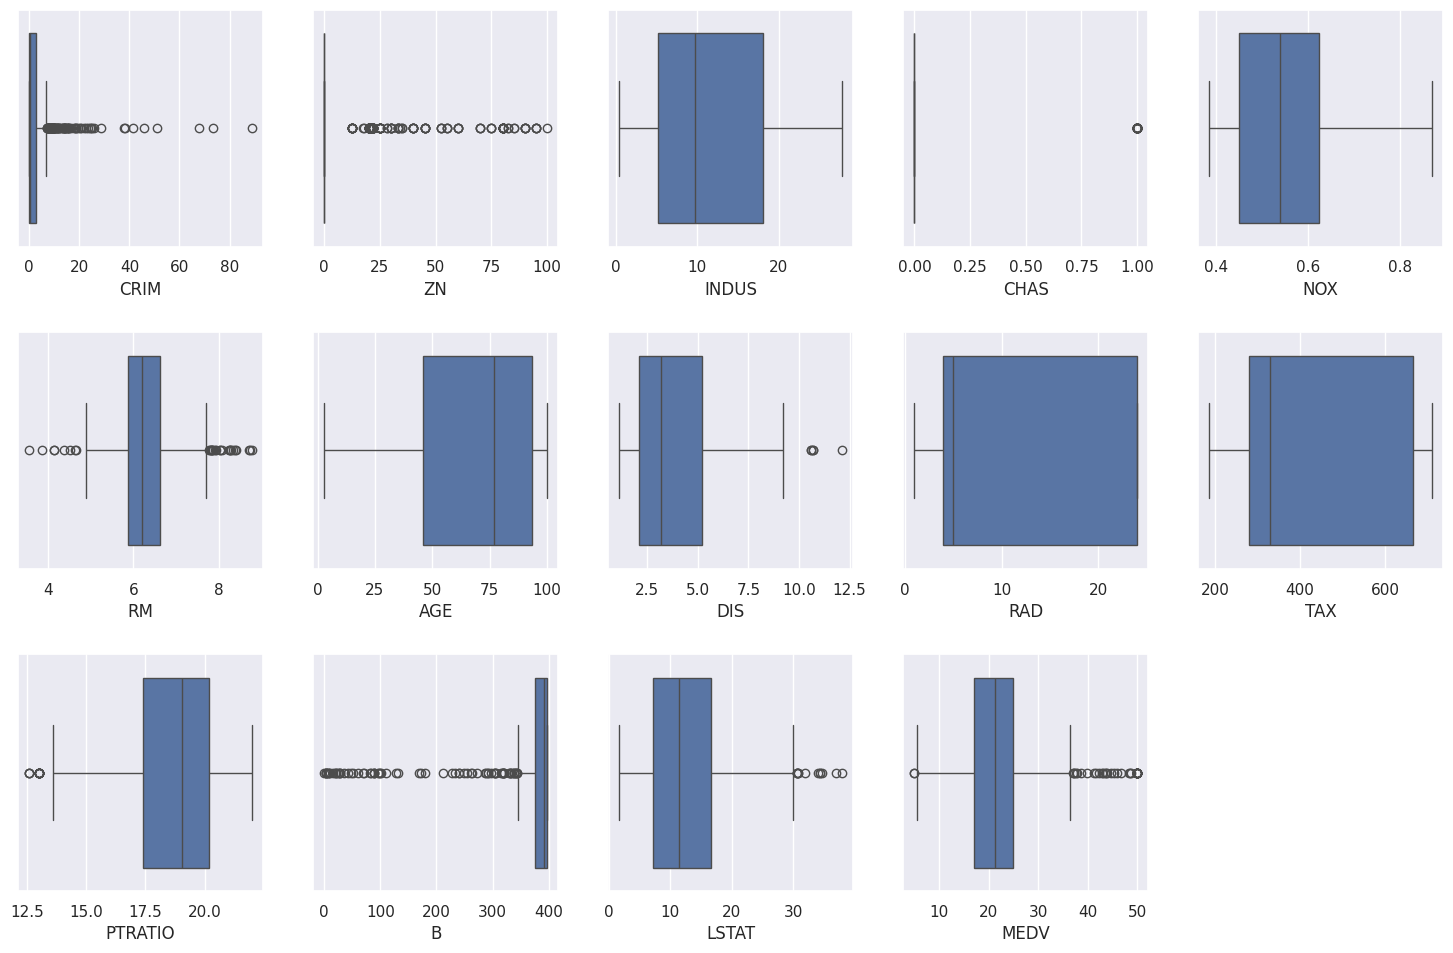

In [69]:
# outlier detection using boxplot
num_cols = df1.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 10))

for i, variable in enumerate(num_cols):
    plt.subplot(3, 5, i + 1)
    sns.boxplot(data=df1, x=variable)
    plt.tight_layout(pad=2)

plt.show()

In [70]:
# Winsorization using scipy
from scipy.stats.mstats import winsorize
df1["ZN"] = winsorize(df1["ZN"], limits=[0, 0.05])

In [71]:
df1.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.006,18.000,2.310,0.000,0.538,6.575,65.200,4.090,1,296,15.300,396.900,4.980,24.000
1,0.027,0.000,7.070,0.000,0.469,6.421,78.900,4.967,2,242,17.800,396.900,9.140,21.600
2,0.027,0.000,7.070,0.000,0.469,7.185,61.100,4.967,2,242,17.800,392.830,4.030,34.700
3,0.032,0.000,2.180,0.000,0.458,6.998,45.800,6.062,3,222,18.700,394.630,2.940,33.400
4,0.069,0.000,2.180,0.000,0.458,7.147,54.200,6.062,3,222,18.700,396.900,11.430,36.200


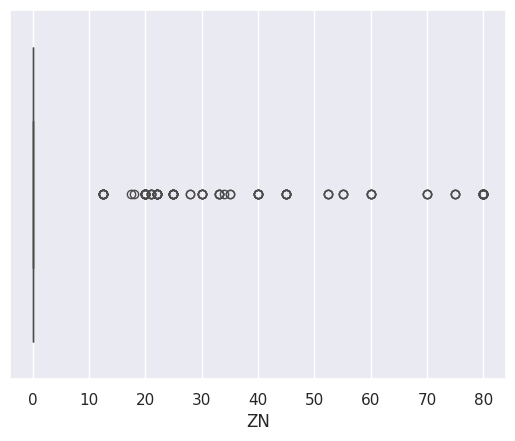

In [72]:
#visualizing the ZN variable
sns.boxplot(data=df1,x="ZN")
plt.show()

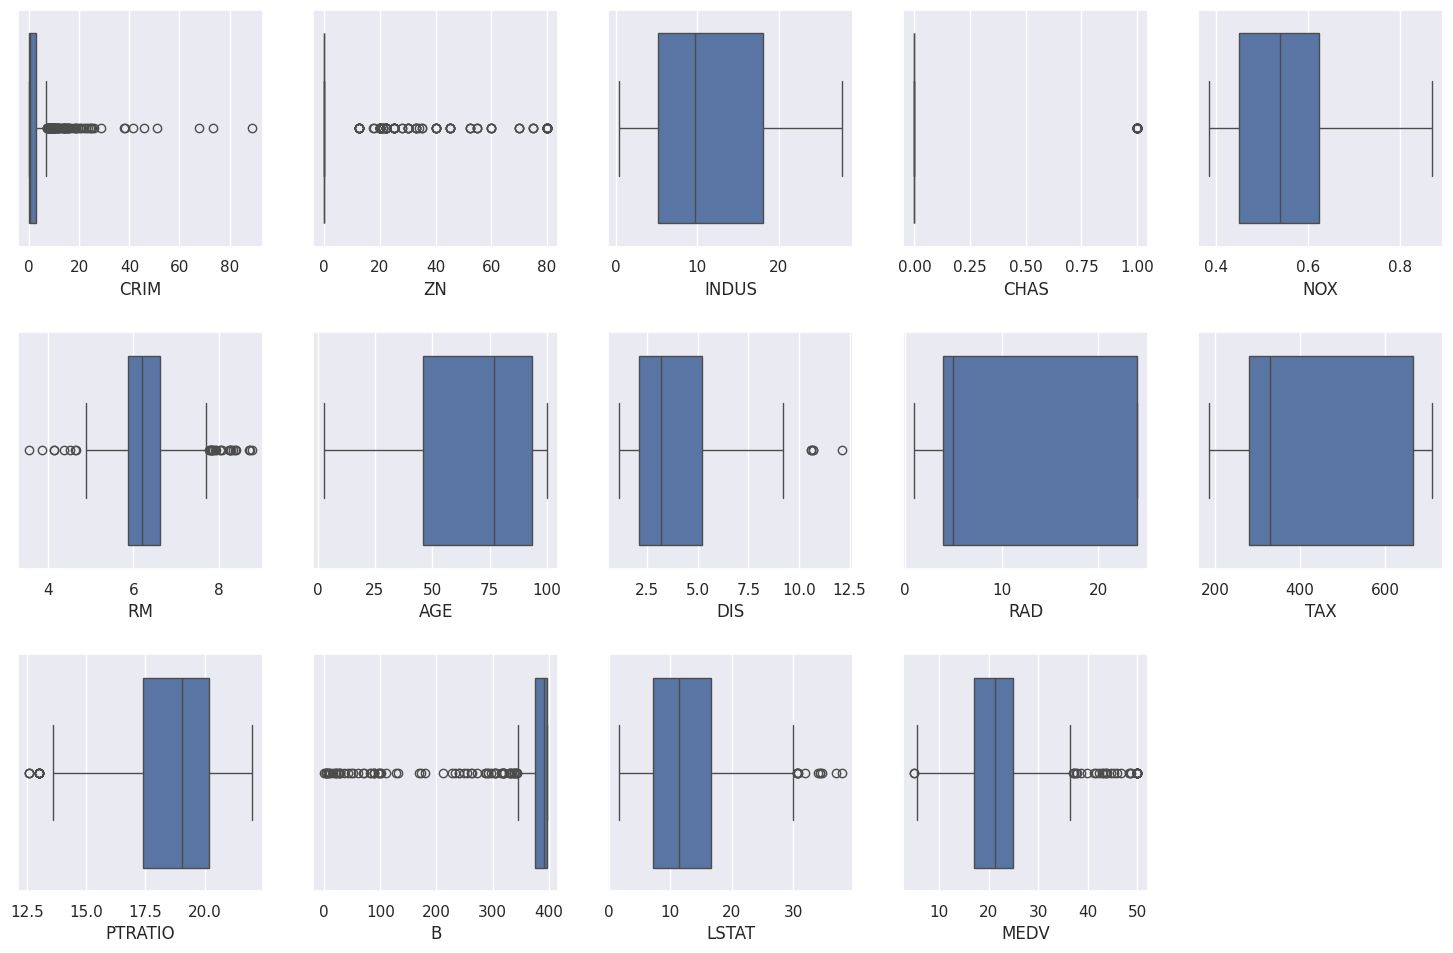

In [73]:
# outlier detection using boxplot
num_cols = df1.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 10))

for i, variable in enumerate(num_cols):
    plt.subplot(3, 5, i + 1)
    sns.boxplot(data=df1, x=variable)
    plt.tight_layout(pad=2)

plt.show()

###4. **Preparing data for modeling**

##### Spliting final data set to 30 percent train data and 70 percent test data.

In [74]:
# defining X and y variables

#Independent variable
X = df1.drop(["MEDV"], axis=1)
#Independent variable
y = df1["MEDV"]

print(X.head())
print(y.head())

   CRIM     ZN  INDUS  CHAS   NOX    RM    AGE   DIS  RAD  TAX  PTRATIO  \
0 0.006 18.000  2.310 0.000 0.538 6.575 65.200 4.090    1  296   15.300   
1 0.027  0.000  7.070 0.000 0.469 6.421 78.900 4.967    2  242   17.800   
2 0.027  0.000  7.070 0.000 0.469 7.185 61.100 4.967    2  242   17.800   
3 0.032  0.000  2.180 0.000 0.458 6.998 45.800 6.062    3  222   18.700   
4 0.069  0.000  2.180 0.000 0.458 7.147 54.200 6.062    3  222   18.700   

        B  LSTAT  
0 396.900  4.980  
1 396.900  9.140  
2 392.830  4.030  
3 394.630  2.940  
4 396.900 11.430  
0   24.000
1   21.600
2   34.700
3   33.400
4   36.200
Name: MEDV, dtype: float64


In [75]:
# let's add the intercept to data
X = sm.add_constant(X)

In [76]:
# splitting the data in 70:30 ratio for train to test data

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [44]:
print("Number of rows in train data =", x_train.shape[0])
print("Number of rows in test data =", x_test.shape[0])

Number of rows in train data = 354
Number of rows in test data = 152


In [77]:
print(df1.isna().sum())

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [78]:


# 2. Check for Infs per column
# We use np.isinf() because pandas doesn't have a native .isinf()
print("\nInf count per column:")
print(np.isinf(df1).sum())


Inf count per column:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


## Feature Selection

## Model Building - Linear Regression

Lets build a linear regression model based on the processed data.

In [79]:
#Building regression model with train data
olsmodel = sm.OLS(y_train, x_train).fit()
print(olsmodel.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.702
Model:                            OLS   Adj. R-squared:                  0.691
Method:                 Least Squares   F-statistic:                     61.74
Date:                Fri, 16 Jan 2026   Prob (F-statistic):           3.37e-81
Time:                        14:03:51   Log-Likelihood:                -1066.0
No. Observations:                 354   AIC:                             2160.
Df Residuals:                     340   BIC:                             2214.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         45.2418      6.416      7.051      0.0

## Model Performance Check

Let's check the performance of the model using different metrics.

* We will be using metric functions defined in sklearn for RMSE, MAE, and $R^2$.
* We will define a function to calculate MAPE and adjusted $R^2$.
    
    
* We will create a function which will print out all the above metrics in one go.

In [80]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute MAPE
def mape_score(targets, predictions):
    return np.mean(np.abs(targets - predictions) / targets) * 100


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mape_score(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df2_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df2_perf

In [81]:
# checking model performance on train set (seen 70% data)
print("Training Performance\n")
olsmodel_train_perf = model_performance_regression(olsmodel, x_train, y_train)
olsmodel_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,4.915,3.384,0.702,0.690,16.858


In [82]:
# checking model performance on test set (seen 30% data)
print("Test Performance\n")
olsmodel_test_perf = model_performance_regression(olsmodel, x_test, y_test)
olsmodel_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,4.608,3.462,0.768,0.745,16.998


###**Checking and managing multicolinearity**

- I wil be checking multicolinearities with Variance Inflation factor(VIF).
- For this model, I will tolorated moderate multicolinearities upto 7.

So, lets define custom function to check for multicolinearity.

**Checking Multicolinearity**

In [83]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


def checking_vif(predictors):
    vif = pd.DataFrame()
    vif["feature"] = predictors.columns

    # calculating VIF for each feature
    vif["VIF"] = [
        variance_inflation_factor(predictors.values, i)
        for i in range(len(predictors.columns))
    ]
    return vif

In [84]:
#Displaying VIF results
checking_vif(x_train)

,feature,VIF
0,const,579.395
1,CRIM,1.909
2,ZN,2.661
3,INDUS,3.714
4,CHAS,1.076
5,NOX,4.187
6,RM,1.807
7,AGE,2.769
8,DIS,4.394
9,RAD,8.272


**Managing Multicolinearity**

To remove multicollinearity

1. Drop every column one by one that has a VIF score greater than 7.
2. Look at the adjusted R-squared and RMSE of all these models.
3. Drop the variable that makes the least change in adjusted R-squared.
4. Check the VIF scores again.
5. Continue till you get all VIF scores under 7.

I will be using a custom define function to carry out this task.

In [85]:
def treating_multicollinearity(predictors, target, high_vif_columns):
    """
    Checking the effect of dropping the columns showing high multicollinearity
    on model performance (adj. R-squared and RMSE)

    predictors: independent variables
    target: dependent variable
    high_vif_columns: columns having high VIF
    """
    # empty lists to store adj. R-squared and RMSE values
    adj_r2 = []
    rmse = []

    # build ols models by dropping one of the high VIF columns at a time
    # store the adjusted R-squared and RMSE in the lists defined previously
    for cols in high_vif_columns:
        # defining the new train set
        train = predictors.loc[:, ~predictors.columns.str.startswith(cols)]

        # create the model
        olsmodel = sm.OLS(target, train).fit()

        # adding adj. R-squared and RMSE to the lists
        adj_r2.append(olsmodel.rsquared_adj)
        rmse.append(np.sqrt(olsmodel.mse_resid))

    # creating a dataframe for the results
    temp = pd.DataFrame(
        {
            "col": high_vif_columns,
            "Adj. R-squared after_dropping col": adj_r2,
            "RMSE after dropping col": rmse,
        }
    ).sort_values(by="Adj. R-squared after_dropping col", ascending=False)
    temp.reset_index(drop=True, inplace=True)

    return temp

####Checking TAX vs RAD for multicolinearity.

In [86]:
#Checking the impact on the when either of the variables are dropped.
col_list = ["TAX", "RAD"]

res = treating_multicollinearity(x_train, y_train, col_list)
res

,col,Adj. R-squared after_dropping col,RMSE after dropping col
0,TAX,0.689,5.035
1,RAD,0.683,5.081


In [87]:
#Dropping the variable introducing multicolinearity and renaming the test and training data for predictors
col_to_drop = "TAX"
x_train2 = x_train.drop(col_to_drop, axis=1)
x_test2 = x_test.drop(col_to_drop, axis=1)

# Check VIF now
vif = checking_vif(x_train2)
print("VIF after dropping ", col_to_drop)
vif

VIF after dropping  TAX


,feature,VIF
0,const,577.405
1,CRIM,1.906
2,ZN,2.409
3,INDUS,3.056
4,CHAS,1.049
5,NOX,4.136
6,RM,1.806
7,AGE,2.768
8,DIS,4.376
9,RAD,2.922


Now that all multicolinearities has been cleared, lets run the regression again.

In [88]:
#Reruning model with optimized values
olsmodel1 = sm.OLS(y_train, x_train2).fit()
print(olsmodel1.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.699
Model:                            OLS   Adj. R-squared:                  0.689
Method:                 Least Squares   F-statistic:                     66.06
Date:                Fri, 16 Jan 2026   Prob (F-statistic):           2.44e-81
Time:                        14:13:31   Log-Likelihood:                -1067.9
No. Observations:                 354   AIC:                             2162.
Df Residuals:                     341   BIC:                             2212.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         44.5221      6.430      6.924      0.0

- Re-running the model with optimized data has lead to reduction in p values of a lot of variables, some variables have p values that have reduced to significance levels

Having dealt with multicolinearities,let's turn our attention to eliminating insignificant variables with high p values.

###**Dealing with High P-values**

- Some P-values of the variable are greater than 0.05,hence will be dropping them ones at a time starting from the highest,just to see how it affect the p-values of the rest variables.
- When the there are no more variables with p-values greater than 0.05,then the task is completed.Then I will proceed to testing assumptions for linear regression.
- I will be defining and using a custom function for this task.

In [89]:
# initial list of columns
predictors = x_train2.copy()
cols = predictors.columns.tolist()

# setting an initial max p-value
max_p_value = 1

while len(cols) > 0:
    # defining the train set
    x_train_aux = predictors[cols]

    # fitting the model
    model = sm.OLS(y_train, x_train_aux).fit()

    # getting the p-values and the maximum p-value
    p_values = model.pvalues
    max_p_value = max(p_values)

    # name of the variable with maximum p-value
    feature_with_p_max = p_values.idxmax()

    if max_p_value > 0.05:
        cols.remove(feature_with_p_max)
    else:
        break

selected_features = cols
print(selected_features)

['const', 'CRIM', 'ZN', 'CHAS', 'NOX', 'RM', 'DIS', 'RAD', 'PTRATIO', 'LSTAT']


renaming dataset with optimised p-values(high p-values removed)

In [90]:
# Renaming training and test data set with newly optimized values
x_train3 = x_train2[selected_features]
x_test3 = x_test2[selected_features]

- Running regression model again to check new performance

In [91]:
# Re-running model with newly optimized data
olsmodel2 = sm.OLS(y_train, x_train3).fit()
print(olsmodel2.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.695
Model:                            OLS   Adj. R-squared:                  0.687
Method:                 Least Squares   F-statistic:                     87.13
Date:                Fri, 16 Jan 2026   Prob (F-statistic):           3.23e-83
Time:                        14:15:33   Log-Likelihood:                -1070.3
No. Observations:                 354   AIC:                             2161.
Df Residuals:                     344   BIC:                             2199.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         47.9188      6.153      7.788      0.0


- P values for the remaning significant variables reduced tremendiously.

###**Checking model performance again**

In [92]:
# checking model performance on train set (seen 70% data)
print("Training Performance\n")
olsmodel_train_perf = model_performance_regression(olsmodel2, x_train3, y_train)
olsmodel_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,4.976,3.462,0.695,0.686,17.307


In [93]:
# checking model performance on test set (seen 30% data)
print("Test Performance\n")
olsmodel_test_perf = model_performance_regression(olsmodel2, x_test3, y_test)
olsmodel_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,4.813,3.645,0.747,0.729,17.848


## Checking Linear Regression Assumptions

- In order to make statistical inferences from a linear regression model, it is important to ensure that the assumptions of linear regression are satisfied.

- Test for multicolinearity has been done and handled earlier,so we will not do it again in this section.

###**Test of Linearity and Independence**

To check for linearity and independence, we will do the following:
- Make a plot of fitted values vs residuals.
- If they don't follow any pattern, then we say the model is linear and residuals are independent.
- Otherwise, the model is showing signs of non-linearity and residuals are not independent.


In [94]:
# let us create a dataframe with actual, fitted and residual values
df_pred = pd.DataFrame()

df_pred["Actual Values"] = y_train  # actual values
df_pred["Fitted Values"] = olsmodel2.fittedvalues  # predicted values
df_pred["Residuals"] = olsmodel2.resid  # residuals

df_pred.head()

,Actual Values,Fitted Values,Residuals
13,20.400,19.243,1.157
61,16.000,18.067,-2.067
377,13.300,18.746,-5.446
39,30.800,31.371,-0.571
365,27.500,15.686,11.814


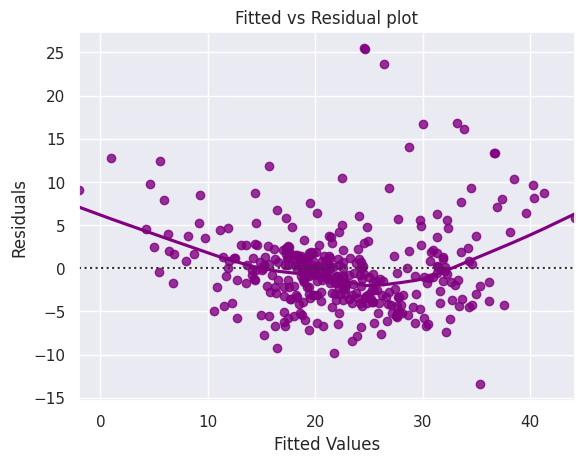

In [95]:
# let's plot the fitted values vs residuals

sns.residplot(
    data=df_pred, x="Fitted Values", y="Residuals", color="purple", lowess=True
)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Fitted vs Residual plot")
plt.show()

**Observations**

- From the above plot, the residuals are showing a clear pattern
-

In [100]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import pandas as pd

# 1. Initialize PolynomialFeatures (degree 2 is usually enough)
# This will create X^2 terms and interactions (X1 * X2)
poly = PolynomialFeatures(degree=2, include_bias=False)

# 2. Transform your features (using your significant features from the OLS)
features = ['LSTAT', 'RM', 'PTRATIO', 'DIS', 'NOX']
X_poly = poly.fit_transform(df1[features])

# 3. Re-run your regression
# You can use Statsmodels again to see the new R-squared and Residual Plot
import statsmodels.api as sm
X_poly_df = pd.DataFrame(X_poly, columns=poly.get_feature_names_out(features))
X_poly_df = sm.add_constant(X_poly_df)

model_poly = sm.OLS(df['MEDV'], X_poly_df).fit()
print(model_poly.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.837
Model:                            OLS   Adj. R-squared:                  0.830
Method:                 Least Squares   F-statistic:                     124.3
Date:                Fri, 16 Jan 2026   Prob (F-statistic):          2.46e-176
Time:                        14:25:53   Log-Likelihood:                -1381.6
No. Observations:                 506   AIC:                             2805.
Df Residuals:                     485   BIC:                             2894.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          -150.3084     60.304     -2.493

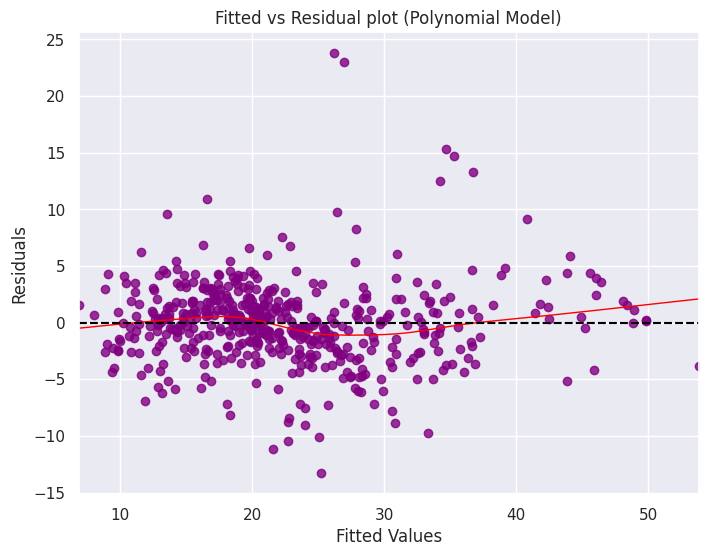

In [102]:


# 1. Extract the values from the fitted model
fitted_values = model_poly.fittedvalues
residuals = model_poly.resid

# 2. Plot using the extracted arrays (No 'data=' argument needed for arrays)
plt.figure(figsize=(8, 6))
sns.residplot(
    x=fitted_values,
    y=residuals,
    color="purple",
    lowess=True,
    line_kws={'color': 'red', 'lw': 1} # Optional: makes the trend line red to stand out
)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Fitted vs Residual plot (Polynomial Model)")
plt.axhline(y=0, color='black', linestyle='--') # Add the zero-line reference
plt.show()

###**Test of normality**

We will be checking for residual normality following these steps.

- Plot histogram  of the distribution of residuals.The shape of the histogram of residuals can give an initial idea about the normality.
- It can also be checked via a Q-Q plot of residuals. If the residuals follow a normal distribution, they will make a straight line plot, otherwise not.

- An additional test I will perform will be to check for normality using the Shapiro-Wilk test. Whose interpretation will be as follow:

Null hypothesis: Residuals are normally distributed

Alternate hypothesis: Residuals are not normally distributed

P value greater than 0.05 means the null hypothesis will be accepted.

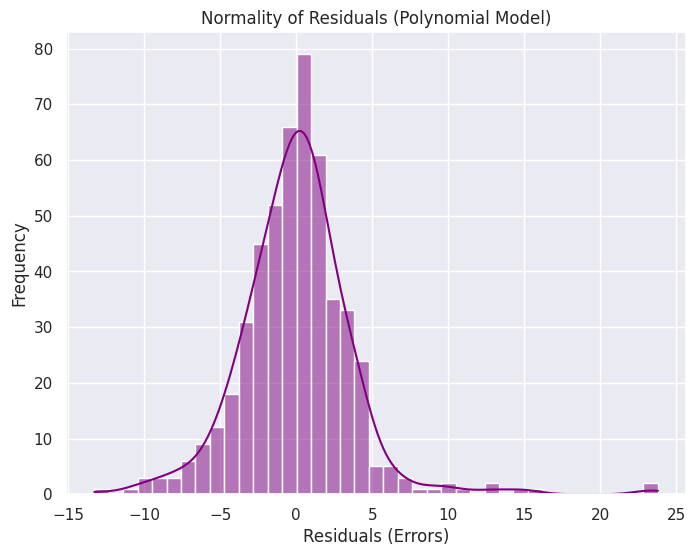

In [103]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extract residuals from the Polynomial Model
# These are the errors AFTER accounting for non-linearity
poly_residuals = model_poly.resid

# 2. Create a specific DataFrame for prediction results
df_pred_poly = pd.DataFrame({
    'Residuals': poly_residuals
})

# 3. Plot the distribution
plt.figure(figsize=(8, 6))
sns.histplot(data=df_pred_poly, x="Residuals", kde=True, color="purple")

plt.title("Normality of Residuals (Polynomial Model)")
plt.xlabel("Residuals (Errors)")
plt.ylabel("Frequency")
plt.show()

- The distribution of residuals though slightly skewwed to the left could be considered normal, thus condition for

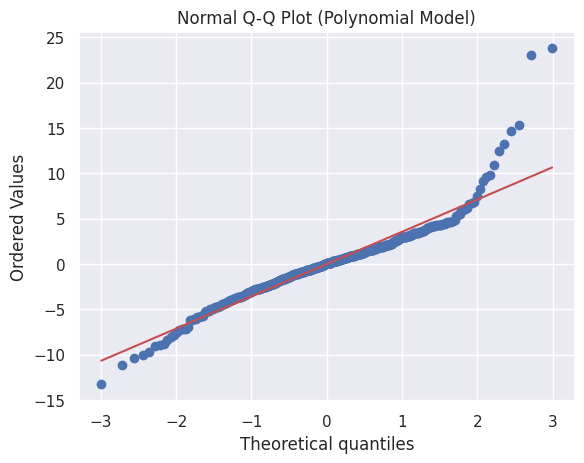

In [104]:
# 1. Extract residuals from the Polynomial Model
poly_residuals = model_poly.resid

# 2. Generate the Probability Plot
# We use the residuals from the model that handled non-linearity
stats.probplot(poly_residuals, dist="norm", plot=pylab)

plt.title("Normal Q-Q Plot (Polynomial Model)")
plt.show()

In [ ]:
#Running Shapiro-wilks test
stats.shapiro(df_pred["Residuals"])

ShapiroResult(statistic=0.969733476638794, pvalue=3.583213733486345e-22)

P-values are less than 0.05 which means the distribution of residuals deviate significantly from a normal distribution.
However, since the deviation from normal is very insignificant as seen in the histogram plot, Assumption of normality of residuals will be accepted.

###**Test of Homoscedasticity**

- We will carry out the following steps to test for homoscedascity of residuals:


The goldfeldquandt test can also be used.

If we get a p-value > 0.05 we can say that the residuals are homoscedastic.

Otherwise, they are heteroscedastic.

Null hypothesis: Residuals are homoscedastic

Alternate hypothesis: Residuals have heteroscedasticity

In [105]:
#Importing required library for test
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

# 1. Use the residuals from the polynomial model
poly_residuals = model_poly.resid

# 2. Use the feature matrix that corresponds to that model
# We drop the constant column if it exists because the test focuses on features
X_features = X_poly_df.drop(columns=['const']) if 'const' in X_poly_df.columns else X_poly_df

# 3. Define the labels
name = ["F statistic", "p-value"]

# 4. Run the Goldfeld-Quandt test
# Note: x refers to the independent variables the test uses to check for variance changes
test = sms.het_goldfeldquandt(poly_residuals, X_features)

# 5. Zip and print results
result = lzip(name, test)
print(result)

[('F statistic', np.float64(2.2170201069062996)), ('p-value', np.float64(1.0325301316145278e-09))]


**Since p-value < 0.05, we can say that the residuals are not homoscedastic. So, this assumption is no satisfied.**

In [106]:
import statsmodels.api as sm

# 1. Re-run the model with 'HC3' robust standard errors
# HC3 is generally considered the best choice for smaller datasets
model_robust = sm.OLS(df['MEDV'], X_poly_df).fit(cov_type='HC3')

# 2. View the new summary
print(model_robust.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.837
Model:                            OLS   Adj. R-squared:                  0.830
Method:                 Least Squares   F-statistic:                     165.3
Date:                Fri, 16 Jan 2026   Prob (F-statistic):          7.65e-202
Time:                        14:37:42   Log-Likelihood:                -1381.6
No. Observations:                 506   AIC:                             2805.
Df Residuals:                     485   BIC:                             2894.
Df Model:                          20                                         
Covariance Type:                  HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const          -150.3084    111.142     -1.352

###**Final Test**

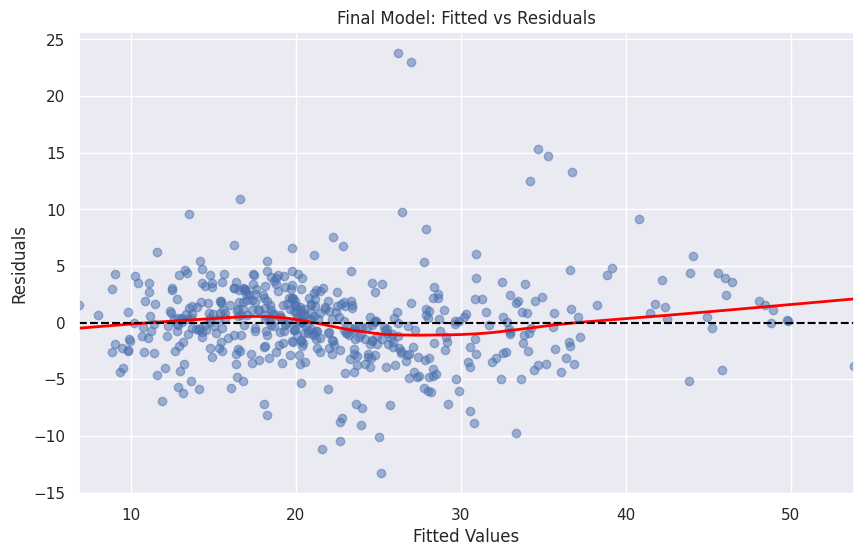

In [107]:


# Extract values from the robust model
fitted_values = model_robust.fittedvalues
residuals = model_robust.resid

plt.figure(figsize=(10, 6))
sns.residplot(x=fitted_values, y=residuals, lowess=True,
              line_kws={'color': 'red', 'lw': 2},
              scatter_kws={'alpha': 0.5})
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Final Model: Fitted vs Residuals')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

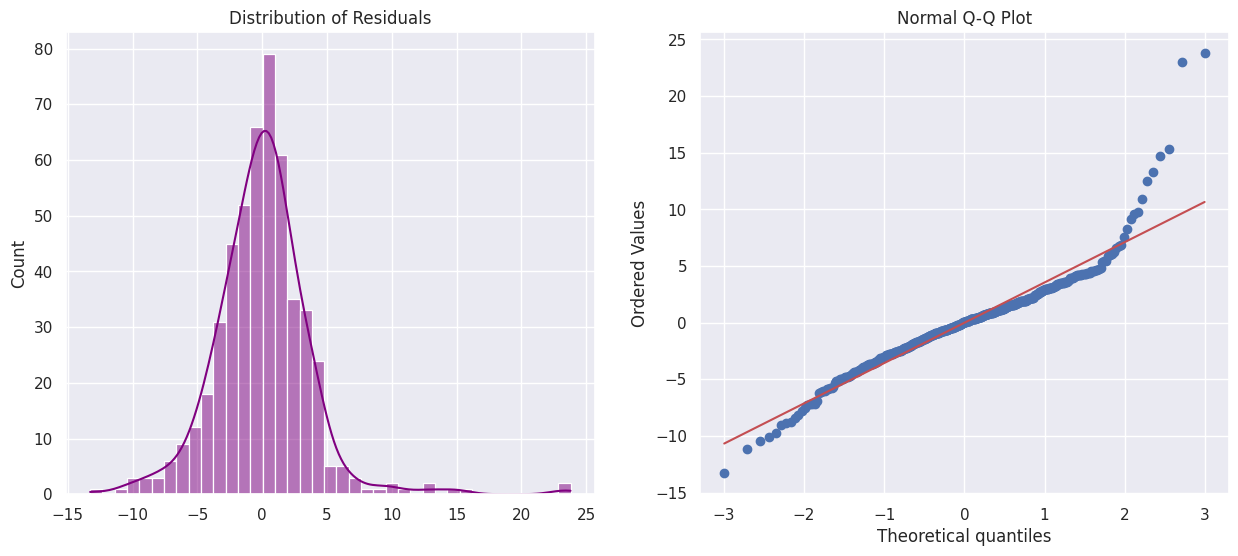

In [108]:
import scipy.stats as stats
import pylab

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Histogram
sns.histplot(residuals, kde=True, ax=ax1, color='purple')
ax1.set_title('Distribution of Residuals')

# Q-Q Plot
stats.probplot(residuals, dist="norm", plot=ax2)
ax2.set_title('Normal Q-Q Plot')

plt.show()

In [109]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# We check VIF on the features used in X_poly_df (excluding the constant)
X_vif = X_poly_df.drop(columns=['const']) if 'const' in X_poly_df.columns else X_poly_df

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))

          Feature       VIF
2         PTRATIO 41158.168
4             NOX 27356.801
1              RM 27344.703
11     RM PTRATIO  8775.815
13         RM NOX  7326.269
14      PTRATIO^2  6761.901
16    PTRATIO NOX  6239.949
3             DIS  4599.107
0           LSTAT  4360.810
10           RM^2  3717.512
19          NOX^2  3211.712
18        DIS NOX  1634.527
12         RM DIS  1544.433
7   LSTAT PTRATIO  1187.974
15    PTRATIO DIS  1018.633
9       LSTAT NOX   855.494
6        LSTAT RM   847.563
17          DIS^2   149.493
8       LSTAT DIS    90.149
5         LSTAT^2    78.115


However, for a Polynomial Regression model, these results are actually expected and mathematically normal, though they require a specific interpretation.
1. Why are the VIFs so high?VIF measures how much a variable is correlated with other variables. When you create polynomial features (like $RM^2$ or $RM \times NOX$), you are intentionally creating variables that are derived from the original ones.Mathematical Necessity: It is impossible for $RM$ and $RM^2$ not to be highly correlated.Redundancy: The high VIF is simply the computer telling you, "Hey, $RM \times NOX$ looks a lot like $RM$ and $NOX$!"

2. Is this "OK" for the final model?The answer depends on your goal:If your goal is Prediction: YES, it is OK. High multicollinearity caused by polynomial terms does not reduce the predictive power of the model. Your $R^2$ and your predictions for house prices remain valid.If your goal is Inference (Interpreting Coeffs): It's tricky. Because the features are so "tangled," you cannot easily say "increasing $RM$ by 1 unit increases price by $X$," because $RM^2$ and $RM \times NOX$ would also have to change.

3. The "Final Model" VerdictSince you are using Robust Standard Errors (HC3), you have already protected your model against the most dangerous side effects of this instability. Your p-values for the coefficients are "honest" despite the high VIF.

How to "Clean" this (Optional)If you want to lower these VIF scores to make the model easier to explain, the standard technique is Mean Centering.By subtracting the average from each variable before squaring/multiplying them, you break the mathematical correlation between the linear and quadratic terms.

In [113]:

from sklearn.preprocessing import PolynomialFeatures
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Select your features
features = ['LSTAT', 'RM', 'PTRATIO', 'DIS', 'NOX']

# 2. Mean Centering: Subtract the mean from each column
# This centers the data around zero
df_centered = df1[features].copy()
for col in features:
    df_centered[col] = df1[col] - df1[col].mean()

# 3. Create Polynomial Features from the centered data
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly_centered = poly.fit_transform(df_centered)

# Create a DataFrame for the new features
X_poly_df = pd.DataFrame(X_poly_centered, columns=poly.get_feature_names_out(features))
X_poly_df = sm.add_constant(X_poly_df)

# 4. Fit the final model with Robust Standard Errors (HC3)
# We use the original target MEDV but the centered polynomial features
final_model = sm.OLS(df['MEDV'], X_poly_df).fit(cov_type='HC3')

# 5. Check VIF again
X_vif = X_poly_df.drop(columns=['const'])
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))
print("\n--- Model Summary ---")
print(final_model.summary())

          Feature    VIF
18        DIS NOX 40.588
19          NOX^2 15.644
17          DIS^2 14.335
8       LSTAT DIS 10.339
9       LSTAT NOX  9.869
3             DIS  7.444
5         LSTAT^2  6.825
4             NOX  6.364
6        LSTAT RM  5.944
13         RM NOX  5.777
16    PTRATIO NOX  5.746
12         RM DIS  5.033
15    PTRATIO DIS  4.229
0           LSTAT  4.143
7   LSTAT PTRATIO  4.019
11     RM PTRATIO  3.543
10           RM^2  3.419
14      PTRATIO^2  3.391
1              RM  2.494
2         PTRATIO  2.253

--- Model Summary ---
                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.837
Model:                            OLS   Adj. R-squared:                  0.830
Method:                 Least Squares   F-statistic:                     165.3
Date:                Fri, 16 Jan 2026   Prob (F-statistic):          7.65e-202
Time:                        14:48:04   Log-Likelihood:  

In [116]:


# 1. Define your significant features
features = ['LSTAT', 'RM', 'PTRATIO', 'DIS', 'NOX']

# 2. Mean Centering: This is the key step to lower VIF
# We subtract the average from each column to center them around zero
df_centered = df1[features].copy()
for col in features:
    df_centered[col] = df1[col] - df1[col].mean()

# 3. Create Polynomial Features from the centered data
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly_centered = poly.fit_transform(df_centered)

# Create a DataFrame for the VIF calculation
# We use poly.get_feature_names_out() to label the new columns correctly
X_vif = pd.DataFrame(X_poly_centered, columns=poly.get_feature_names_out(features))

# 4. Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

# 5. Print the results sorted from highest to lowest VIF
print("New VIF Scores after Mean Centering:")
print(vif_data.sort_values(by="VIF", ascending=False))

New VIF Scores after Mean Centering:
          Feature    VIF
18        DIS NOX 40.588
19          NOX^2 15.644
17          DIS^2 14.335
8       LSTAT DIS 10.339
9       LSTAT NOX  9.869
3             DIS  7.444
5         LSTAT^2  6.825
4             NOX  6.364
6        LSTAT RM  5.944
13         RM NOX  5.777
16    PTRATIO NOX  5.746
12         RM DIS  5.033
15    PTRATIO DIS  4.229
0           LSTAT  4.143
7   LSTAT PTRATIO  4.019
11     RM PTRATIO  3.543
10           RM^2  3.419
14      PTRATIO^2  3.391
1              RM  2.494
2         PTRATIO  2.253


## Final Model

Optimizing train data for centering

In [126]:
# 3. Mean Centering (using train means only)
train_means = x_train[features].mean()
x_train_centered = x_train[features] - train_means

# 4. Polynomial Transformation
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly_train = poly.fit_transform(x_train_centered)

# 5. Create the final Training DataFrame
X_poly_df = pd.DataFrame(X_poly_train, columns=poly.get_feature_names_out(features))
X_poly_df = sm.add_constant(X_poly_df)

print(f"X_poly_df rows: {len(X_poly_df)}") # Should be 354

X_poly_df rows: 354


optimizing test data for Centering

In [119]:
# 1. MEAN CENTERING: Use the MEANS from your training set (very important!)
# Replace 'df_train' with your original training dataframe name
train_means = df1[features].mean()
x_test_centered = x_test[features] - train_means

# 2. POLYNOMIAL TRANSFORMATION: Transform the centered test data
# 'poly' is the PolynomialFeatures object you fit earlier
x_test_poly = poly.transform(x_test_centered)

In [120]:
# 3. CONVERT TO DATAFRAME: Add labels and the constant (intercept)
x_test_final = pd.DataFrame(x_test_poly, columns=poly.get_feature_names_out(features))
x_test_final = sm.add_constant(x_test_final)

Recreating the final Model and printing results to gain more insights

In [117]:
#Running final model
final_model = sm.OLS(df['MEDV'], X_poly_df).fit(cov_type='HC3')
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.837
Model:                            OLS   Adj. R-squared:                  0.830
Method:                 Least Squares   F-statistic:                     165.3
Date:                Fri, 16 Jan 2026   Prob (F-statistic):          7.65e-202
Time:                        14:52:40   Log-Likelihood:                -1381.6
No. Observations:                 506   AIC:                             2805.
Df Residuals:                     485   BIC:                             2894.
Df Model:                          20                                         
Covariance Type:                  HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            20.9393      0.532     39.360

**Next check model performance on training and test data and check for over fitting and under fitting**

In [127]:
print("Training Performance\n")
olsmodel_final_train_perf = model_performance_regression(
    final_model, X_poly_df, y_train
)
print(olsmodel_final_train_perf)

Training Performance

   RMSE   MAE  R-squared  Adj. R-squared   MAPE
0 3.902 2.589      0.812           0.801 38.017


In [124]:
#  CHECK PERFORMANCE
print("Final Polynomial Model (Robust) - Test Performance\n")
olsmodel_final_test_perf = model_performance_regression(
    final_model, x_test_final, y_test
)

olsmodel_final_test_perf

Final Polynomial Model (Robust) - Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,3.250,2.556,0.885,0.866,42.431


In [129]:
# predictions on the test set
pred = final_model.predict(x_test_final)

df_pred_test = pd.DataFrame({"Actual": y_test, "Predicted": pred})
df_pred_test.sample(20, random_state=1)

,Actual,Predicted
112,NaN,12.190
292,27.900,NaN
110,21.700,41.807
106,19.500,16.843
298,22.500,NaN
380,10.400,NaN
78,21.200,28.071
501,22.400,NaN
116,NaN,20.072
260,33.800,NaN
